# Unified Analysis Notebook

This notebook orchestrates compute-only pipeline modules in `analysis_pipeline`.
Heavy computations live in `.py` files; this notebook focuses on configuration, execution, validation, and plotting.

## 1. Set Up Environment and Imports

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis_pipeline.config import load_analysis_config, merge_overrides
from analysis_pipeline.pipeline import run_bead_core, run_autocorr_core
from tomsUtilities import tum_colors

plt.style.use('./science.mplstyle.txt')
plt.style.use('dark_background')
pd.set_option('display.max_columns', 200)

ROOT = Path('.')
print('Workspace:', ROOT.resolve())

Workspace: /Users/tom/Uni_local/master_local/analysis


## 2. Define Project Configuration

In [31]:
config_path = ROOT / 'config' / 'analysis_default.yaml'
base_config = load_analysis_config(str(config_path))

# Notebook overrides for rapid iteration.
quick_test_mode = False
quick_test_frames = 2

overrides = {
    'dataset': {
        'dataset_id': 'AMF_095_002__C640_C470',
        'base_dir': '/Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260311',
    },
    'runtime': {
        'skip_existing': not quick_test_mode,
        'verbose': True,
    },
    'beads': {
        'parallel_workers': 0,
        'angular_mode': True,
        # 'channel_to_use': 1,
    },
    'autocorr': {
        'parallel_workers': 0,
        # 'single_frame_3d': 0,
    }
}

# Fast subset mode for parameter tuning before full runs.
if quick_test_mode:
    overrides.setdefault('dataset', {})['tstop'] = int(quick_test_frames)

pipeline_run_mode = 'test' if quick_test_mode else 'full'

config = merge_overrides(base_config, overrides)
config['beads']['compute_angular_speed'] = bool(config['beads'].get('angular_mode', False))
if bool(config['beads'].get('angular_mode', False)):
    config['autocorr']['enabled'] = False
print('Dataset ID:', config['dataset']['dataset_id'])
print('Base dir:', config['dataset']['base_dir'])
print('Pipeline run mode:', pipeline_run_mode)
print('Quick test mode:', quick_test_mode, '| tstop:', config['dataset'].get('tstop'))

Dataset ID: AMF_095_002__C640_C470
Base dir: /Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260311
Pipeline run mode: full
Quick test mode: False | tstop: -1


## 3. Load and Validate Input Data

In [32]:
from analysis_pipeline.io_dataset import load_dataset_state

dataset_id = config['dataset']['dataset_id']
assert isinstance(dataset_id, str) and len(dataset_id) > 0, 'dataset.dataset_id must be non-empty'

base_dir = Path(config['dataset']['base_dir'])
if not base_dir.exists():
    print('Warning: base_dir does not exist locally:', base_dir)

data_state = load_dataset_state(config['dataset'], verbose=True)

print('Config validation passed')
print('Bead stage enabled:', bool(config['beads']['enabled']))
print('Angular mode enabled:', bool(config['beads'].get('angular_mode', False)))
print('Autocorr stage enabled:', bool(config['autocorr']['enabled']))
print('First data load mode:', 'test' if quick_test_mode else 'full')
print('Frame subset (tstop):', config['dataset'].get('tstop'))

Loaded dataset
  id: AMF_095_002__C640_C470
  name: AMF_095_002__C640_C470
  variation: -
  base_dir: /Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260311
  shape (T,C,Z,Y,X): (330, 2, 27, 2818, 2829)
  chunks: (1, 1, 27, 2818, 2829)
  size_gb: 270.96
  channels: 2
  px_per_micron: 3.846
  px_per_micron_z: 0.6667
  fps: 0.04131
  mask channel loaded: False
Config validation passed
Bead stage enabled: True
Angular mode enabled: True
Autocorr stage enabled: False
First data load mode: full
Frame subset (tstop): -1


## 4. Preprocess Data for Implementation

In [33]:
# Pipeline modules handle heavy preprocessing internally.
# This cell prepares notebook-level runtime toggles and expected output paths.

derived_dir = Path('data') / dataset_id / 'derived'
derived_dir.mkdir(parents=True, exist_ok=True)

expected_outputs = {
    'detections': derived_dir / 'beads_detections.parquet',
    'tracks': derived_dir / 'beads_tracks.parquet',
    'tracks_vel': derived_dir / 'beads_tracks_with_velocity.parquet',
    'tracks_ang': derived_dir / 'beads_tracks_with_angular_speed.parquet',
    'ac3d_single': derived_dir / 'autocorr_3d_single_frame.parquet',
    'ac3d_sampled': derived_dir / 'autocorr_3d_sampled.parquet',
    'ac2d_sampled': derived_dir / 'autocorr_2d_sampled.parquet',
    'ac2d_radial': derived_dir / 'autocorr_2d_radial_single.parquet',
}

pd.DataFrame({'artifact': list(expected_outputs.keys()), 'path': [str(v) for v in expected_outputs.values()]})

,artifact,path
0,detections,data/AMF_095_002__C640_C470/derived/beads_dete...
1,tracks,data/AMF_095_002__C640_C470/derived/beads_trac...
2,tracks_vel,data/AMF_095_002__C640_C470/derived/beads_trac...
3,tracks_ang,data/AMF_095_002__C640_C470/derived/beads_trac...
4,ac3d_single,data/AMF_095_002__C640_C470/derived/autocorr_3...
5,ac3d_sampled,data/AMF_095_002__C640_C470/derived/autocorr_3...
6,ac2d_sampled,data/AMF_095_002__C640_C470/derived/autocorr_2...
7,ac2d_radial,data/AMF_095_002__C640_C470/derived/autocorr_2...


## 5. Implement Core Functions

In [14]:
# Core reusable functions are implemented in analysis_pipeline/*.py.
# Here we add minimal notebook-side wrappers for convenience.

def summarize_track_table(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame({'metric': ['rows', 'particles'], 'value': [0, 0]})
    n_particles = int(df['particle'].nunique()) if 'particle' in df.columns else 0
    return pd.DataFrame({'metric': ['rows', 'particles'], 'value': [int(len(df)), n_particles]})


def summarize_autocorr_table(df: pd.DataFrame, corr_col: str = 'corr') -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame({'metric': ['rows', 'finite_corr'], 'value': [0, 0]})
    finite_corr = int(np.isfinite(df[corr_col]).sum()) if corr_col in df.columns else 0
    return pd.DataFrame({'metric': ['rows', 'finite_corr'], 'value': [int(len(df)), finite_corr]})

print('Notebook helper functions ready')

Notebook helper functions ready


## 6. Assemble and Run Initial Pipeline

Pipeline execution mode: full
Loaded dataset
  id: AMF_095_002__C640_C470
  name: AMF_095_002__C640_C470
  variation: -
  base_dir: /Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260311
  shape (T,C,Z,Y,X): (330, 2, 27, 2818, 2829)
  chunks: (1, 1, 27, 2818, 2829)
  size_gb: 270.96
  channels: 2
  px_per_micron: 3.846
  px_per_micron_z: 0.6667
  fps: 0.04131
  mask channel loaded: False


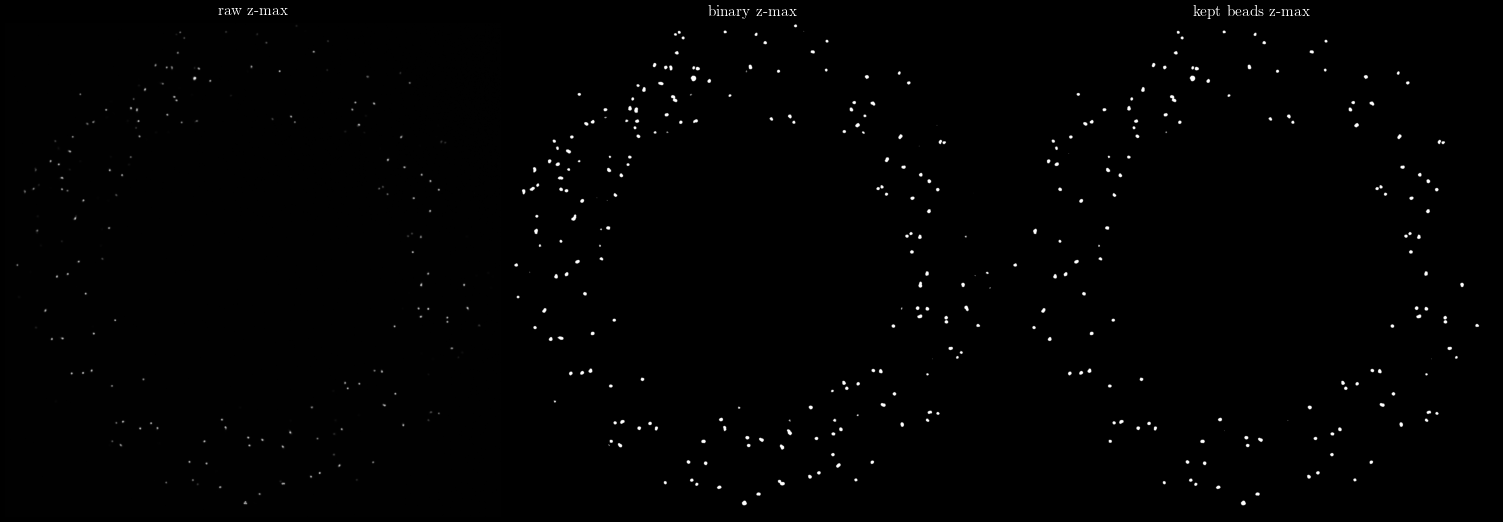

Loaded existing bead detections/tracks from disk
Loaded existing velocity tracks from disk
Loaded existing angular speed tracks from disk
Angular mode enabled: skipping autocorr stage
Pipeline run complete


In [34]:
bead_out = None
autocorr_out = None
state_for_autocorr = None

print('Pipeline execution mode:', 'test' if quick_test_mode else 'full')

if bool(config['beads']['enabled']):
    bead_out = run_bead_core(config)
    state_for_autocorr = bead_out['state'] if bead_out is not None else None

if bool(config['autocorr']['enabled']) and not bool(config['beads'].get('angular_mode', False)):
    autocorr_out = run_autocorr_core(config, state=state_for_autocorr)
elif bool(config['beads'].get('angular_mode', False)):
    print('Angular mode enabled: skipping autocorr stage')

print('Pipeline run complete')

## 7. Compute Evaluation Metrics

In [35]:
# Reload artifacts from disk to keep notebook state independent of in-memory objects.
tracks_vel_df = pd.read_parquet(expected_outputs['tracks_vel']) if expected_outputs['tracks_vel'].exists() else pd.DataFrame()
ac3d_sampled_df = pd.read_parquet(expected_outputs['ac3d_sampled']) if expected_outputs['ac3d_sampled'].exists() else pd.DataFrame()
ac2d_sampled_df = pd.read_parquet(expected_outputs['ac2d_sampled']) if expected_outputs['ac2d_sampled'].exists() else pd.DataFrame()

metrics_rows = []
metrics_rows.append({'metric': 'tracks_vel_rows', 'value': int(len(tracks_vel_df))})
metrics_rows.append({'metric': 'tracks_vel_particles', 'value': int(tracks_vel_df['particle'].nunique()) if 'particle' in tracks_vel_df.columns and len(tracks_vel_df) else 0})
metrics_rows.append({'metric': 'tracks_vel_speed_finite', 'value': int(np.isfinite(tracks_vel_df['speed_um_s']).sum()) if 'speed_um_s' in tracks_vel_df.columns and len(tracks_vel_df) else 0})
metrics_rows.append({'metric': 'ac3d_sampled_rows', 'value': int(len(ac3d_sampled_df))})
metrics_rows.append({'metric': 'ac3d_finite_xi', 'value': int(np.isfinite(ac3d_sampled_df['xi_um']).sum()) if 'xi_um' in ac3d_sampled_df.columns and len(ac3d_sampled_df) else 0})
metrics_rows.append({'metric': 'ac2d_sampled_rows', 'value': int(len(ac2d_sampled_df))})
metrics_rows.append({'metric': 'ac2d_finite_xi', 'value': int(np.isfinite(ac2d_sampled_df['xi_um']).sum()) if 'xi_um' in ac2d_sampled_df.columns and len(ac2d_sampled_df) else 0})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,metric,value
0,tracks_vel_rows,48296
1,tracks_vel_particles,15306
2,tracks_vel_speed_finite,32990
3,ac3d_sampled_rows,0
4,ac3d_finite_xi,0
5,ac2d_sampled_rows,0
6,ac2d_finite_xi,0


## 8. Plot Results for Quick Validation

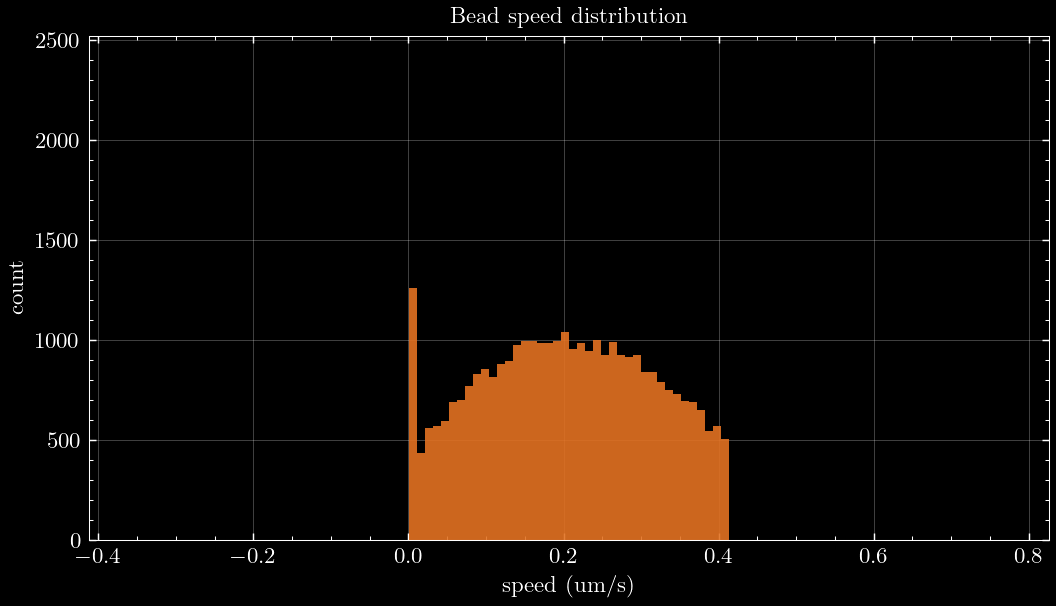

No sampled 3D decay data to plot


In [36]:
plot_dir = Path('plots') / dataset_id / str(config['dataset'].get('variation', ''))
plot_dir.mkdir(parents=True, exist_ok=True)


def _save_dual_pdf(fig, stem: str):
    # Save dark version exactly as rendered in notebook.
    out_dark = plot_dir / f"{stem}_black.pdf"
    fig.savefig(out_dark, dpi=150, bbox_inches='tight')


def _white_style_context():
    return plt.style.context([
        './science.mplstyle.txt',
        {
            'figure.facecolor': 'white',
            'axes.facecolor': 'white',
            'savefig.facecolor': 'white',
            'text.color': 'black',
            'axes.labelcolor': 'black',
            'axes.edgecolor': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'grid.color': '0.8',
            'legend.edgecolor': '0.5',
        },
    ])


def _save_dual_replot(stem: str, plot_fn):
    # Re-plot with the science style on a white background for paper-ready output.
    with _white_style_context():
        fig_w, ax_w = plt.subplots(figsize=(7, 4), dpi=150)
        plot_fn(ax_w)
        fig_w.savefig(plot_dir / f"{stem}_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w)


def _ordered_hot_colors(n: int):
    if n <= 1:
        return np.array([tum_colors[0]])
    cmap = plt.get_cmap('hot')
    values = np.linspace(0.18, 1.0, n)
    return np.array([cmap(v) for v in values])


def _legend_scale(fig):
    width, height = fig.get_size_inches()
    base = min(width, height)
    fontsize = max(10, min(16, int(round(base * 1.4))))
    return {
        'fontsize': fontsize,
        'title_fontsize': fontsize,
        'handlelength': 2.2,
        'labelspacing': 0.6,
        'borderpad': 0.8,
        'handletextpad': 0.7,
        'columnspacing': 1.2,
    }


# Plot A: speed distribution
if len(tracks_vel_df) and 'speed_um_s' in tracks_vel_df.columns:
    speed_vals = tracks_vel_df['speed_um_s'].to_numpy(dtype=float)
    speed_vals = speed_vals[np.isfinite(speed_vals)]
else:
    speed_vals = np.array([])

if speed_vals.size > 0:
    fig_speed, ax_speed = plt.subplots(figsize=(7, 4), dpi=150)
    ax_speed.hist(speed_vals, bins=40, color=tum_colors[0], alpha=0.9)
    ax_speed.set_xlabel('speed (um/s)')
    ax_speed.set_ylabel('count')
    ax_speed.set_title('Bead speed distribution')
    ax_speed.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_speed, f"{dataset_id}_speed_distribution")

    def _speed_plot_white(ax):
        ax.hist(speed_vals, bins=40, color=tum_colors[0], alpha=0.9)
        ax.set_xlabel('speed (um/s)')
        ax.set_ylabel('count')
        ax.set_title('Bead speed distribution')
        ax.grid(True, alpha=0.25)

    _save_dual_replot(f"{dataset_id}_speed_distribution", _speed_plot_white)
else:
    print('No finite speed values to plot')


# Plot B: sampled 3D decay length vs time (parity with old notebooks)
if len(ac3d_sampled_df) and {'time_s', 'xi_um'}.issubset(ac3d_sampled_df.columns):
    xi_3d = (
        ac3d_sampled_df[['time_s', 'frame', 'xi_um', 'xi_err_um']]
        .drop_duplicates(subset=['frame'])
        .sort_values('time_s')
    )
else:
    xi_3d = pd.DataFrame()

if len(xi_3d):
    x_3d = xi_3d['time_s'].to_numpy(dtype=float)
    y_3d = xi_3d['xi_um'].to_numpy(dtype=float)
    yerr_3d = xi_3d['xi_err_um'].to_numpy(dtype=float) if 'xi_err_um' in xi_3d.columns else None
    colors_3d = _ordered_hot_colors(len(x_3d))

    fig_decay3d, ax_decay3d = plt.subplots(figsize=(7, 4), dpi=150)
    for idx in range(len(x_3d)):
        ax_decay3d.errorbar(
            x_3d[idx],
            y_3d[idx],
            yerr=None if yerr_3d is None else yerr_3d[idx],
            fmt='o',
            color=colors_3d[idx],
            ecolor='gray',
            capsize=3,
        )
    ax_decay3d.plot(x_3d, y_3d, color='gray', alpha=0.5)
    ax_decay3d.set_xlabel('time (s)')
    ax_decay3d.set_ylabel('decay length xi (um)')
    ax_decay3d.set_title('Sampled 3D autocorrelation decay length over time')
    ax_decay3d.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_decay3d, f"{dataset_id}_ac3d_decay_over_time")

    def _decay3d_plot_white(ax):
        for idx in range(len(x_3d)):
            ax.errorbar(
                x_3d[idx],
                y_3d[idx],
                yerr=None if yerr_3d is None else yerr_3d[idx],
                fmt='o',
                color=colors_3d[idx],
                ecolor='gray',
                capsize=3,
            )
        ax.plot(x_3d, y_3d, color='gray', alpha=0.5)
        ax.set_xlabel('time (s)')
        ax.set_ylabel('decay length xi (um)')
        ax.set_title('Sampled 3D autocorrelation decay length over time')
        ax.grid(True, alpha=0.25)

    _save_dual_replot(f"{dataset_id}_ac3d_decay_over_time", _decay3d_plot_white)
else:
    print('No sampled 3D decay data to plot')

Rendering displacement overlay animation: 329 frames (step=1)
  rendering frame 1/329 (t=1)
  rendering frame 1/329 (t=1)
  rendering frame 2/329 (t=2)
  rendering frame 3/329 (t=3)
  rendering frame 4/329 (t=4)
  rendering frame 5/329 (t=5)
  rendering frame 6/329 (t=6)
  rendering frame 7/329 (t=7)
  rendering frame 8/329 (t=8)
  rendering frame 9/329 (t=9)


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1050x1044', '-pix_fmt', 'rgba', '-framerate', '10', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-b', '12000k', '-y', 'plots/AMF_095_002__C640_C470/AMF_095_002__C640_C470_beads_displacement_per_frame_overlay.mp4']' returned non-zero exit status 255.

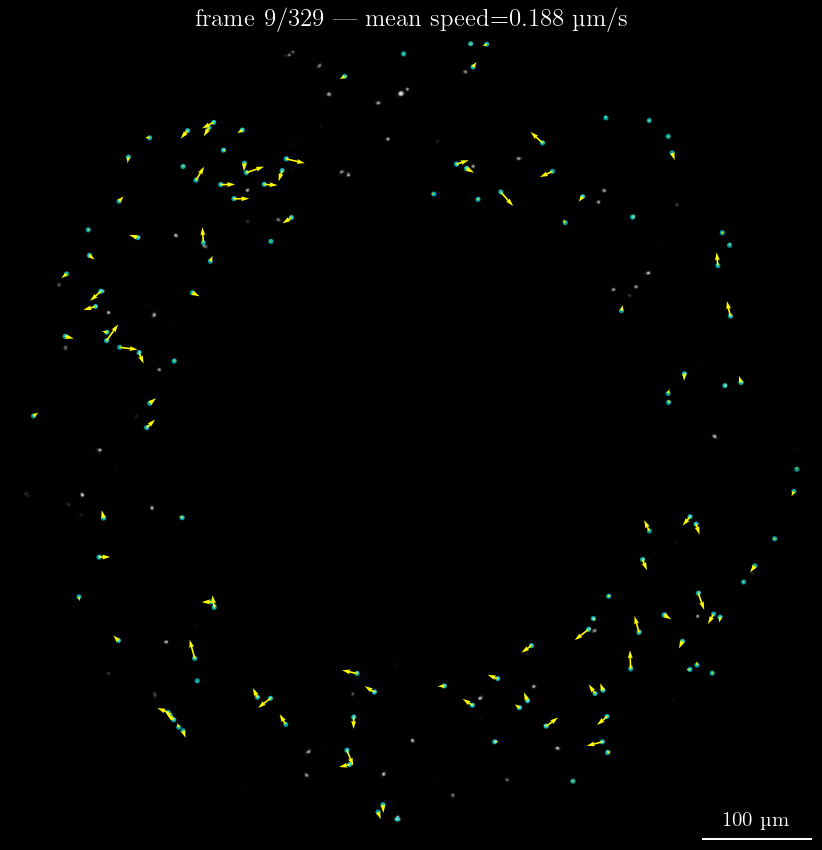

In [37]:
from tomsUtilities import animate_bead_displacement_per_frame_overlay

if 'data_state' not in globals() or data_state is None:
    data_state = load_dataset_state(config['dataset'], verbose=True)

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) > 0:
    bead_channel = int(config['beads'].get('channel_to_use', 1))
    px_per_micron = float(data_state['calibration']['px_per_micron'])
    out_overlay = plot_dir / f"{dataset_id}_beads_displacement_per_frame_overlay.mp4"
    animate_bead_displacement_per_frame_overlay(
        data_state['images'],
        tracks_vel_df,
        out_path=str(out_overlay),
        px_per_micron=px_per_micron,
        bead_channel=bead_channel,
        frame_step=1,
        vector_scale=2.0,
        max_vectors=3000,
        fps=10,
        dpi=150,
        show_title=True,
        verbose=True,
        progress_every=1,
    )
    print('Saved displacement overlay to', out_overlay)
else:
    print('No velocity tracks available for overlay animation')

## 9. Parity Plots (3D/2D Autocorr Profiles)

This section reproduces the core profile-style validation plots from the previous notebooks using saved compute outputs.

In [49]:
ac3d_single_df = pd.read_parquet(expected_outputs['ac3d_single']) if expected_outputs['ac3d_single'].exists() else pd.DataFrame()
ac2d_radial_df = pd.read_parquet(expected_outputs['ac2d_radial']) if expected_outputs['ac2d_radial'].exists() else pd.DataFrame()


def _apply_data_limits(ax, x_vals, y_vals, x_pad_frac=0.05, y_pad_frac=0.08, x_lower=None, x_upper=None):
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if not np.any(valid):
        return
    x = x[valid]
    y = y[valid]
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    y_min = float(np.nanmin(y))
    y_max = float(np.nanmax(y))
    if x_max > x_min:
        x_pad = x_pad_frac * (x_max - x_min)
        left = x_min - x_pad if x_lower is None else max(x_lower, x_min - x_pad)
        right = x_max + x_pad if x_upper is None else min(x_upper, x_max + x_pad)
        ax.set_xlim(left, right)
    if y_max > y_min:
        y_pad = y_pad_frac * (y_max - y_min)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)


def _ordered_hot_colors(n: int):
    if n <= 1:
        return np.array([tum_colors[0]])
    cmap = plt.get_cmap('hot')
    values = np.linspace(0.18, 1.0, n)
    return np.array([cmap(v) for v in values])


def _legend_scale(fig):
    width, height = fig.get_size_inches()
    base = min(width, height)
    fontsize = max(10, min(16, int(round(base * 1.4))))
    return {
        'fontsize': fontsize,
        'title_fontsize': fontsize,
        'handlelength': 2.2,
        'labelspacing': 0.6,
        'borderpad': 0.8,
        'handletextpad': 0.7,
        'columnspacing': 1.2,
    }


def _format_decay_label(row, frame_label: str):
    parts = [frame_label]
    xi_value = row.get('xi_um', np.nan)
    xi_err = row.get('xi_err_um', np.nan)
    if np.isfinite(xi_value):
        if np.isfinite(xi_err):
            parts.append(rf'$\xi={xi_value:.2f}\pm{xi_err:.2f}$ $\mu$m')
        else:
            parts.append(rf'$\xi={xi_value:.2f}$ $\mu$m')
    tau_value = row.get('tau_s', np.nan)
    tau_err = row.get('tau_err_s', np.nan)
    if np.isfinite(tau_value):
        if np.isfinite(tau_err):
            parts.append(rf'$\tau={tau_value:.2f}\pm{tau_err:.2f}$ s')
        else:
            parts.append(rf'$\tau={tau_value:.2f}$ s')
    return ' | '.join(parts)


# 3D sampled autocorr profiles per sampled frame
if len(ac3d_sampled_df):
    fig_prof3d, ax_prof3d = plt.subplots(figsize=(8, 5), dpi=150)
    grouped_3d = list(ac3d_sampled_df.groupby('frame', sort=True))
    colors_3d = _ordered_hot_colors(len(grouped_3d))
    for (fr, g), color in zip(grouped_3d, colors_3d):
        g = g.sort_values('r_um')
        first_row = g.iloc[0]
        t_label = first_row['time_s'] if 'time_s' in g.columns else float(fr)
        label = _format_decay_label(first_row, f'fr {fr} ({t_label:.1f}s)')
        ax_prof3d.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=label)
    ax_prof3d.set_xlabel(r'$r$ ($\mu$m)')
    ax_prof3d.set_ylabel(r'$C(r)/C(0)$')
    ax_prof3d.set_title(r'Sampled 3D autocorrelation profiles')
    ax_prof3d.grid(True, alpha=0.25)
    ax_prof3d.legend(loc='upper right', frameon=True, **_legend_scale(fig_prof3d))
    _apply_data_limits(ax_prof3d, ac3d_sampled_df['r_um'], ac3d_sampled_df['corr'])
    plt.tight_layout()
    plt.show()

    fig_prof3d.savefig(plot_dir / f"{dataset_id}_sampled_autocorr_profiles_black.pdf", dpi=150, bbox_inches='tight')
    with plt.style.context([
        './science.mplstyle.txt',
        {
            'figure.facecolor': 'white',
            'axes.facecolor': 'white',
            'savefig.facecolor': 'white',
            'text.color': 'black',
            'axes.labelcolor': 'black',
            'axes.edgecolor': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'grid.color': '0.8',
            'legend.edgecolor': '0.5',
        },
    ]):
        fig_w, ax_w = plt.subplots(figsize=(8, 5), dpi=150)
        for (fr, g), color in zip(grouped_3d, colors_3d):
            g = g.sort_values('r_um')
            first_row = g.iloc[0]
            t_label = first_row['time_s'] if 'time_s' in g.columns else float(fr)
            label = _format_decay_label(first_row, f'fr {fr} ({t_label:.1f}s)')
            ax_w.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=label)
        ax_w.set_xlabel(r'$r$ ($\mu$m)')
        ax_w.set_ylabel(r'$C(r)/C(0)$')
        ax_w.grid(True, alpha=0.25)
        ax_w.legend(loc='upper right', frameon=True, **_legend_scale(fig_w))
        _apply_data_limits(ax_w, ac3d_sampled_df['r_um'], ac3d_sampled_df['corr'])
        fig_w.savefig(plot_dir / f"{dataset_id}_sampled_autocorr_profiles_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w)
else:
    print('No sampled 3D profiles available')

# 2D sampled autocorr profiles per sampled frame
if len(ac2d_sampled_df):
    fig_prof2d, ax_prof2d = plt.subplots(figsize=(8, 5), dpi=150)
    grouped_2d = list(ac2d_sampled_df.groupby('frame', sort=True))
    colors_2d = _ordered_hot_colors(len(grouped_2d))
    for (fr, g), color in zip(grouped_2d, colors_2d):
        g = g.sort_values('r_um')
        first_row = g.iloc[0]
        t_label = first_row['time_s'] if 'time_s' in g.columns else float(fr)
        label = _format_decay_label(first_row, f'fr {fr} ({t_label:.1f}s)')
        ax_prof2d.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=label)
    ax_prof2d.set_xlabel(r'$r$ ($\mu$m)')
    ax_prof2d.set_ylabel(r'$C(r)/C(0)$')
    ax_prof2d.set_title(r'Sampled 2D autocorrelation profiles')
    ax_prof2d.grid(True, alpha=0.25)
    ax_prof2d.legend(loc='upper right', frameon=True, **_legend_scale(fig_prof2d))
    _apply_data_limits(ax_prof2d, ac2d_sampled_df['r_um'], ac2d_sampled_df['corr'])
    plt.tight_layout()
    plt.show()

    fig_prof2d.savefig(plot_dir / f"{dataset_id}_sampled_2d_autocorr_profiles_black.pdf", dpi=150, bbox_inches='tight')
    with plt.style.context([
        './science.mplstyle.txt',
        {
            'figure.facecolor': 'white',
            'axes.facecolor': 'white',
            'savefig.facecolor': 'white',
            'text.color': 'black',
            'axes.labelcolor': 'black',
            'axes.edgecolor': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'grid.color': '0.8',
            'legend.edgecolor': '0.5',
        },
    ]):
        fig_w2, ax_w2 = plt.subplots(figsize=(8, 5), dpi=150)
        for (fr, g), color in zip(grouped_2d, colors_2d):
            g = g.sort_values('r_um')
            first_row = g.iloc[0]
            t_label = first_row['time_s'] if 'time_s' in g.columns else float(fr)
            label = _format_decay_label(first_row, f'fr {fr} ({t_label:.1f}s)')
            ax_w2.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=label)
        ax_w2.set_xlabel(r'$r$ ($\mu$m)')
        ax_w2.set_ylabel(r'$C(r)/C(0)$')
        ax_w2.grid(True, alpha=0.25)
        ax_w2.legend(loc='upper right', frameon=True, **_legend_scale(fig_w2))
        _apply_data_limits(ax_w2, ac2d_sampled_df['r_um'], ac2d_sampled_df['corr'])
        fig_w2.savefig(plot_dir / f"{dataset_id}_sampled_2d_autocorr_profiles_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w2)
else:
    print('No sampled 2D profiles available')

# Single-frame 3D and radial 2D sanity curves
if len(ac3d_single_df):
    fig_s3d, ax_s3d = plt.subplots(figsize=(7, 4), dpi=150)
    g3 = ac3d_single_df.sort_values('r_um')
    ax_s3d.plot(g3['r_um'].to_numpy(), g3['corr'].to_numpy(), marker='.', lw=1.5, color=tum_colors[0])
    ax_s3d.set_xlabel(r'$r$ ($\mu$m)')
    ax_s3d.set_ylabel(r'$C(r)/C(0)$')
    ax_s3d.set_title(r'Single-frame 3D autocorrelation')
    ax_s3d.grid(True, alpha=0.25)
    _apply_data_limits(ax_s3d, g3['r_um'], g3['corr'])
    plt.tight_layout()
    plt.show()

if len(ac2d_radial_df):
    fig_r2d, ax_r2d = plt.subplots(figsize=(7, 4), dpi=150)
    g2 = ac2d_radial_df.sort_values('r_um')
    ax_r2d.plot(g2['r_um'].to_numpy(), g2['corr'].to_numpy(), marker='.', lw=1.5, color=tum_colors[0])
    ax_r2d.set_xlabel(r'$r$ ($\mu$m)')
    ax_r2d.set_ylabel(r'$C(r)/C(0)$')
    ax_r2d.set_title(r'Single-frame radial 2D autocorrelation')
    ax_r2d.grid(True, alpha=0.25)
    _apply_data_limits(ax_r2d, g2['r_um'], g2['corr'])
    plt.tight_layout()
    plt.show()

# Persist summary table and artifact manifest for reproducibility
metrics_out = derived_dir / 'core_metrics_summary.parquet'
metrics_df.to_parquet(metrics_out, index=False)

artifacts_df = pd.DataFrame(
    {
        'artifact': list(expected_outputs.keys()),
        'exists': [p.exists() for p in expected_outputs.values()],
        'path': [str(p) for p in expected_outputs.values()],
    }
)
artifacts_out = derived_dir / 'core_artifacts_manifest.parquet'
artifacts_df.to_parquet(artifacts_out, index=False)

print('Saved metrics to', metrics_out)
print('Saved artifact manifest to', artifacts_out)
print('Output directory:', derived_dir)
print('Plot directory:', plot_dir)
display(artifacts_df)

No sampled 3D profiles available
No sampled 2D profiles available
Saved metrics to data/AMF_095_002__C640_C470/derived/core_metrics_summary.parquet
Saved artifact manifest to data/AMF_095_002__C640_C470/derived/core_artifacts_manifest.parquet
Output directory: data/AMF_095_002__C640_C470/derived
Plot directory: plots/AMF_095_002__C640_C470


,artifact,exists,path
0,detections,True,data/AMF_095_002__C640_C470/derived/beads_dete...
1,tracks,True,data/AMF_095_002__C640_C470/derived/beads_trac...
2,tracks_vel,True,data/AMF_095_002__C640_C470/derived/beads_trac...
3,tracks_ang,True,data/AMF_095_002__C640_C470/derived/beads_trac...
4,ac3d_single,False,data/AMF_095_002__C640_C470/derived/autocorr_3...
5,ac3d_sampled,False,data/AMF_095_002__C640_C470/derived/autocorr_3...
6,ac2d_sampled,False,data/AMF_095_002__C640_C470/derived/autocorr_2...
7,ac2d_radial,False,data/AMF_095_002__C640_C470/derived/autocorr_2...


Loaded existing angular speed tracks from disk


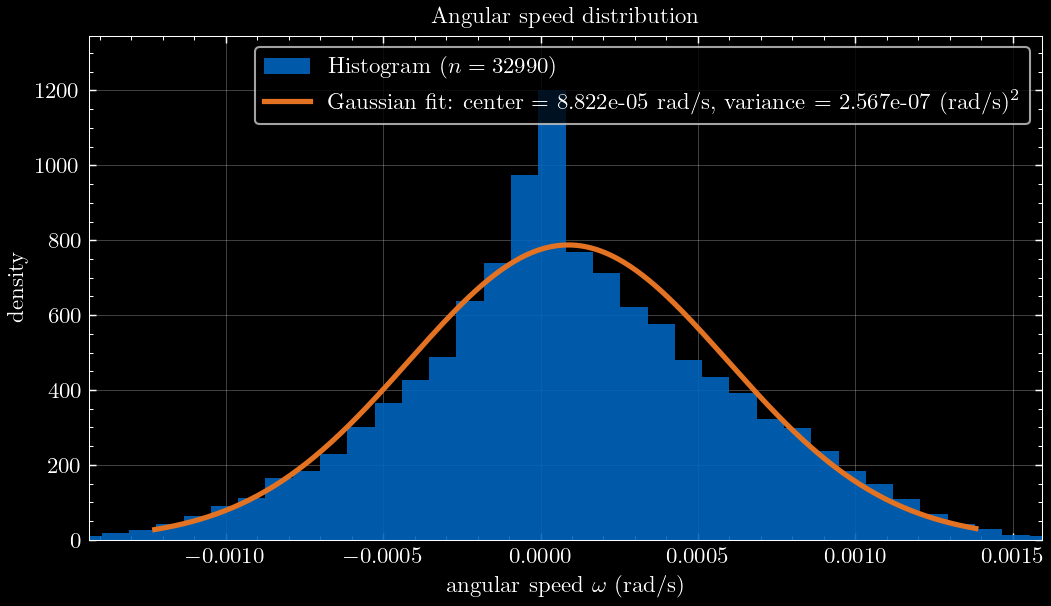

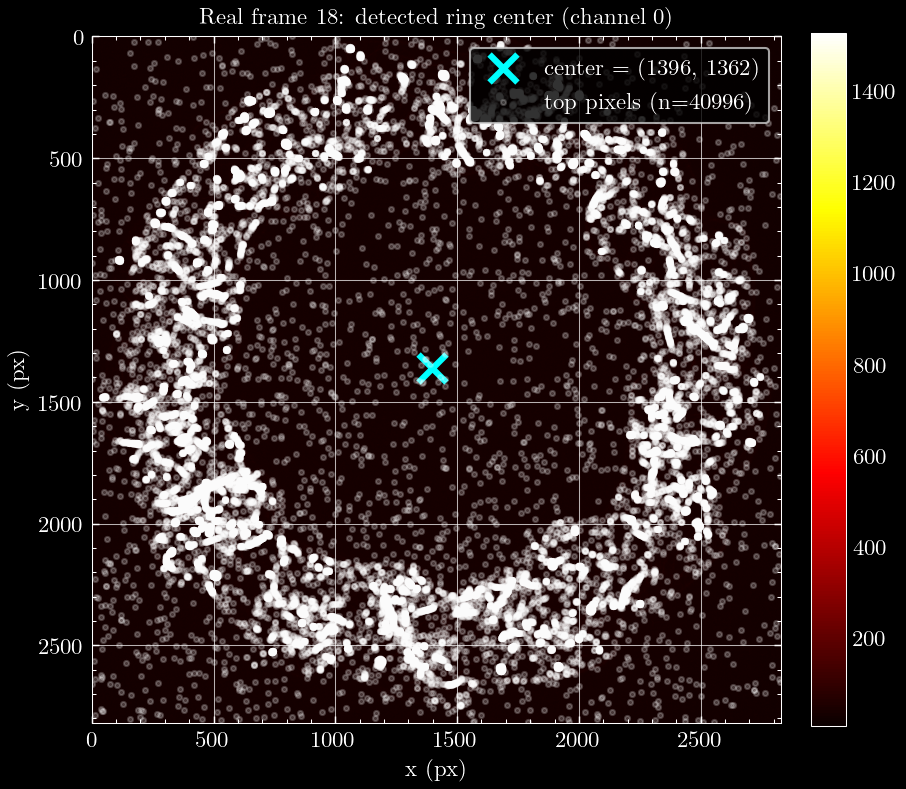

Real frame: 18
Real detected center (x, y): (1396, 1362)
Real bright-pixel threshold: 86
Angular speed sample size: 32990
Gaussian center (mu): 8.82168e-05 rad/s
Gaussian variance: 2.56703e-07 (rad/s)^2


In [17]:
from analysis_pipeline.beads_velocity import compute_angular_speed_xy
from analysis_pipeline.io_dataset import load_dataset_state
from scipy.optimize import minimize
from scipy.stats import norm

angular_mode = bool(config['beads'].get('angular_mode', False))
state_for_autocorr = (
    globals().get('state_for_autocorr')
    or (globals().get('autocorr_out') or {}).get('state')
    or (globals().get('bead_out') or {}).get('state')
    or load_dataset_state(config['dataset'], verbose=True)
)

if angular_mode:
    ang_df = compute_angular_speed_xy(state_for_autocorr, tracks_vel_df, config['beads'], skip_existing=True)
    omega = ang_df['omega_rad_s'].to_numpy(dtype=float) if 'omega_rad_s' in ang_df.columns else np.array([])
    omega = omega[np.isfinite(omega)]
else:
    ang_df = pd.DataFrame()
    omega = np.array([])
    print('Angular mode disabled: skipping angular speed computation and distribution plot')


def _detect_ring_center(frame_2d, percentile=99.5, min_pixels=80):
    frame_2d = np.asarray(frame_2d, dtype=float)
    finite = np.isfinite(frame_2d)
    if not np.any(finite):
        raise ValueError('Frame contains no finite pixels')

    values = frame_2d[finite]
    threshold = float(np.percentile(values, percentile))
    bright_mask = frame_2d >= threshold
    if int(bright_mask.sum()) < int(min_pixels):
        flat = frame_2d.ravel()
        k = min(int(min_pixels), flat.size)
        keep = np.argpartition(flat, -k)[-k:]
        bright_mask = np.zeros_like(frame_2d, dtype=bool)
        bright_mask.ravel()[keep] = True
        threshold = float(np.min(flat[keep]))

    coords = np.argwhere(bright_mask)
    weights = np.clip(frame_2d[bright_mask], a_min=0.0, a_max=None)
    if coords.size == 0:
        center_yx = np.array(np.unravel_index(int(np.nanargmax(frame_2d)), frame_2d.shape), dtype=float)
    elif np.all(weights == 0):
        center_yx = coords.mean(axis=0).astype(float)
    else:
        center_yx = np.average(coords, axis=0, weights=weights).astype(float)

    def _symmetry_cost(center_yx_candidate):
        cy, cx = center_yx_candidate
        distances = np.sqrt((coords[:, 0] - cy) ** 2 + (coords[:, 1] - cx) ** 2)
        if distances.size == 0:
            return np.inf
        distance_spread = np.average((distances - np.average(distances, weights=weights)) ** 2, weights=weights)
        radial_bias = -np.average(frame_2d[bright_mask], weights=weights)
        return float(distance_spread + 1e-6 * radial_bias)

    result = minimize(
        _symmetry_cost,
        x0=center_yx,
        method='Powell',
        options={'xtol': 1e-2, 'ftol': 1e-4, 'maxiter': 200},
    )
    if result.success and np.all(np.isfinite(result.x)):
        center_yx = np.asarray(result.x, dtype=float)

    center_yx[0] = float(np.clip(center_yx[0], 0, frame_2d.shape[0] - 1))
    center_yx[1] = float(np.clip(center_yx[1], 0, frame_2d.shape[1] - 1))
    return threshold, bright_mask, np.rint(center_yx).astype(int)


def _frame_to_2d_projection(images, frame_idx, channel_idx):
    frame = images[frame_idx]
    frame = np.asarray(frame.compute() if hasattr(frame, 'compute') else frame)
    if frame.ndim == 4:
        channel_idx = int(np.clip(channel_idx, 0, frame.shape[0] - 1))
        frame = frame[channel_idx]
    elif frame.ndim == 3 and frame.shape[0] <= 4 and frame.shape[-1] != frame.shape[-2]:
        channel_idx = int(np.clip(channel_idx, 0, frame.shape[0] - 1))
        frame = frame[channel_idx]
    if frame.ndim == 3:
        frame_2d = frame.max(axis=0)
    elif frame.ndim == 2:
        frame_2d = frame
    else:
        raise ValueError(f'Unexpected frame shape for center detection: {frame.shape}')
    return np.asarray(frame_2d, dtype=float)


def _set_hist_limits(ax, values, hist_peak=None, pad_frac=0.08, lower_pct=0.5, upper_pct=99.5):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return
    left, right = np.nanpercentile(values, [lower_pct, upper_pct])
    left = float(left)
    right = float(right)
    span = right - left
    if span > 0:
        pad = pad_frac * span
        ax.set_xlim(left - pad, right + pad)
    if hist_peak is not None and np.isfinite(hist_peak):
        ax.set_ylim(0.0, float(hist_peak) * 1.12)


channel_to_use = 0
frame_counts = ang_df['frame'].value_counts().sort_values(ascending=False) if len(ang_df) else pd.Series(dtype=int)
frame_to_show = int(frame_counts.index[0]) if len(frame_counts) else 0
frame_2d = _frame_to_2d_projection(state_for_autocorr['images'], frame_to_show, channel_to_use)
threshold_real, bright_mask_real, center_real = _detect_ring_center(frame_2d, percentile=99.5, min_pixels=80)

if omega.size > 0:
    omega_mu, omega_sigma = norm.fit(omega)
    omega_var = float(omega_sigma ** 2)
    omega_x = np.linspace(*np.nanpercentile(omega, [0.5, 99.5]), 400) if omega.size > 1 else np.array([omega_mu])
    omega_pdf = norm.pdf(omega_x, loc=omega_mu, scale=omega_sigma) if omega_sigma > 0 else np.zeros_like(omega_x)
    omega_ymax = float(max(np.nanmax(omega_pdf) if omega_pdf.size else 0.0, 1e-12))
    fig_omega, ax_omega = plt.subplots(figsize=(7, 4), dpi=150)
    hist_vals, hist_bins, _ = ax_omega.hist(
        omega,
        bins=40,
        density=True,
        color=tum_colors[1],
        alpha=0.9,
        label=rf'Histogram ($n={omega.size}$)',
    )
    if omega_sigma > 0:
        ax_omega.plot(
            omega_x,
            omega_pdf,
            color=tum_colors[0],
            lw=2.5,
            label=rf'Gaussian fit: center = {omega_mu:.4g} rad/s, variance = {omega_var:.4g} (rad/s)$^2$',
        )
        omega_ymax = max(omega_ymax, float(np.nanmax(omega_pdf)))
    ax_omega.set_xlabel(r'angular speed $\omega$ (rad/s)')
    ax_omega.set_ylabel('density')
    ax_omega.set_title('Angular speed distribution')
    ax_omega.grid(True, alpha=0.25)
    _set_hist_limits(ax_omega, omega, hist_peak=hist_vals.max() if hist_vals.size else None)
    ax_omega.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_omega, f'{dataset_id}_angular_speed_distribution')

    def _omega_plot_white(ax):
        ax.hist(
            omega,
            bins=40,
            density=True,
            color=tum_colors[1],
            alpha=0.9,
            label=rf'Histogram ($n={omega.size}$)',
        )
        if omega_sigma > 0:
            ax.plot(
                omega_x,
                omega_pdf,
                color=tum_colors[0],
                lw=2.5,
                label=rf'Gaussian fit: center = {omega_mu:.4g} rad/s, variance = {omega_var:.4g} (rad/s)$^2$',
            )
        ax.set_xlabel(r'angular speed $\omega$ (rad/s)')
        ax.set_ylabel('density')
        ax.set_title('Angular speed distribution')
        ax.grid(True, alpha=0.25)
        _set_hist_limits(ax, omega, hist_peak=hist_vals.max() if hist_vals.size else None)
        ax.legend(loc='upper right', frameon=True)

    _save_dual_replot(f'{dataset_id}_angular_speed_distribution', _omega_plot_white)
else:
    print('No finite angular speed values available for plotting')

fig_center, ax_center = plt.subplots(figsize=(6, 6), dpi=150)
im = ax_center.imshow(frame_2d, cmap='hot')
ax_center.scatter(center_real[1], center_real[0], s=180, marker='x', color='cyan', linewidths=3, label=f'center = ({center_real[1]}, {center_real[0]})')
bright_yx = np.argwhere(bright_mask_real)
if bright_yx.size:
    ax_center.scatter(bright_yx[:, 1], bright_yx[:, 0], s=6, color='white', alpha=0.22, label=f'top pixels (n={len(bright_yx)})')
ax_center.set_title(f'Real frame {frame_to_show}: detected ring center (channel 0)')
ax_center.set_xlabel('x (px)')
ax_center.set_ylabel('y (px)')
ax_center.legend(loc='upper right', frameon=True)
fig_center.colorbar(im, ax=ax_center, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

_save_dual_pdf(fig_center, f'{dataset_id}_ring_center_validation_real')

print(f'Real frame: {frame_to_show}')
print(f'Real detected center (x, y): ({center_real[1]}, {center_real[0]})')
print(f'Real bright-pixel threshold: {threshold_real:.4g}')
print(f'Angular speed sample size: {omega.size}')
print(f'Gaussian center (mu): {omega_mu:.6g} rad/s' if omega.size > 0 else 'Gaussian center (mu): n/a')
print(f'Gaussian variance: {omega_var:.6g} (rad/s)^2' if omega.size > 0 else 'Gaussian variance: n/a')

## 10. Secondary Analyses

Use this section for comparison analyses that build on the saved compute outputs without breaking the notebook structure.

## 10.1. Channel 1 z-Axis Autocorrelation

This subsection plots the 1D autocorrelation along the z axis for channel 1 on a single frame.

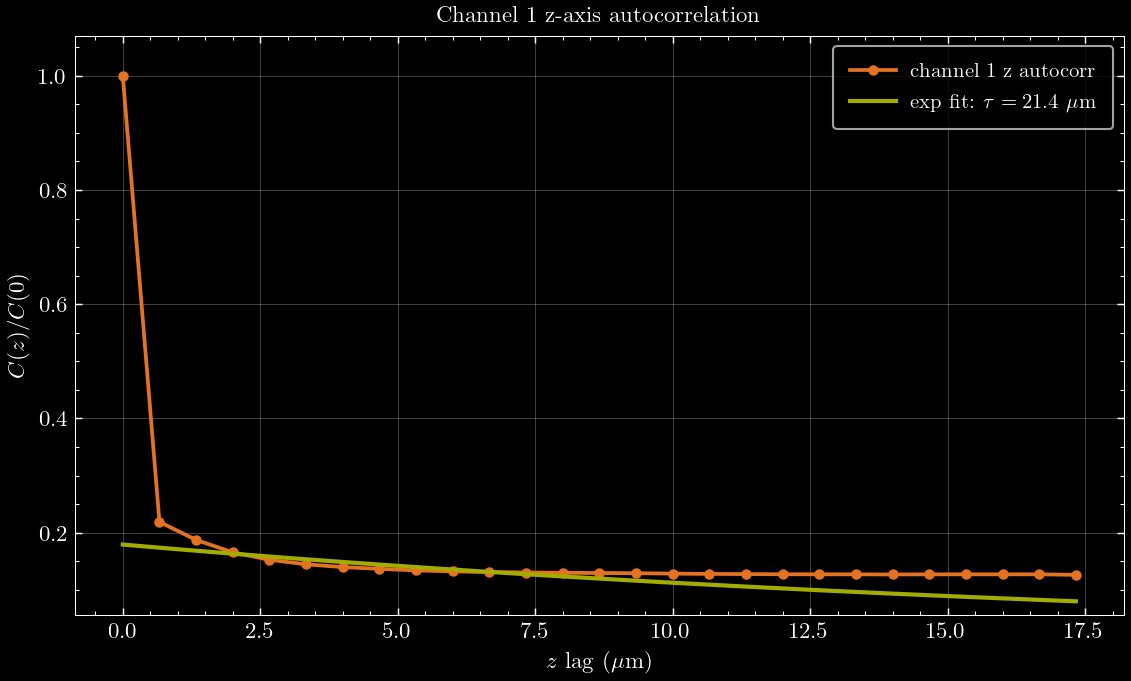

Channel: 0
Frame: 0
Volume shape: (27, 2818, 2829)
Z calibration: 0.6667 px/um
Lag count: 27
Exp fit tau: 21.4129 um


In [51]:
from analysis_pipeline.io_dataset import load_dataset_state
from tomsUtilities import autocorr_1d_axis, fit_exp_decay

state_for_autocorr = (
    globals().get('state_for_autocorr')
    or (globals().get('autocorr_out') or {}).get('state')
    or (globals().get('bead_out') or {}).get('state')
    or load_dataset_state(config['dataset'], verbose=True)
)

images = state_for_autocorr['images']
calibration = state_for_autocorr['calibration']
px_z = float(calibration.get('px_per_micron_z', calibration['px_per_micron']))

frame_idx = 0
channel_idx = 0

volume = images[frame_idx, channel_idx].compute() if hasattr(images[frame_idx, channel_idx], 'compute') else images[frame_idx, channel_idx]
volume = np.asarray(volume, dtype=np.float32)
if volume.ndim != 3:
    raise ValueError(f'Expected a 3D volume for channel 1, got shape {volume.shape}')
if channel_idx > 0 and volume.size == 0:
    raise ValueError('Channel 1 volume is empty')

distances_z, corr_z = autocorr_1d_axis(volume, axis=0, px_scale=px_z)
corr_z = np.asarray(corr_z, dtype=float)
valid = np.isfinite(distances_z) & np.isfinite(corr_z)
distances_z = distances_z[valid]
corr_z = corr_z[valid]

def _apply_axis_limits(ax, x_vals, y_vals, x_pad_frac=0.05, y_pad_frac=0.08):
    """Set tight axis limits with a small padding around finite data."""
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    if not np.any(finite):
        return
    x = x[finite]
    y = y[finite]
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    y_min = float(np.nanmin(y))
    y_max = float(np.nanmax(y))
    if x_max > x_min:
        x_pad = x_pad_frac * (x_max - x_min)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
    if y_max > y_min:
        y_pad = y_pad_frac * (y_max - y_min)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

fit_mask = (distances_z > 0) & np.isfinite(corr_z)
fit_fraction = 0.5
tau_fit = None
amp_fit = None
if np.count_nonzero(fit_mask) >= 2:
    amp_fit, tau_fit = fit_exp_decay(distances_z, corr_z, fit_fraction=fit_fraction)

fig_zcorr, ax_zcorr = plt.subplots(figsize=(7.5, 4.5), dpi=150)
ax_zcorr.plot(distances_z, corr_z, marker='o', ms=4, lw=1.8, color=tum_colors[0], label='channel 1 z autocorr')
ax_zcorr.axhline(0.0, color='gray', lw=1.0, alpha=0.6)
if tau_fit is not None and np.isfinite(tau_fit):
    fit_x = np.linspace(float(distances_z[0]), float(distances_z[-1]), 400)
    fit_y = amp_fit * np.exp(-fit_x / tau_fit) if amp_fit is not None else np.exp(-fit_x / tau_fit)
    ax_zcorr.plot(fit_x, fit_y, color=tum_colors[2], lw=2.0, label=rf'exp fit: $\tau = {tau_fit:.3g}$ $\mu$m')
ax_zcorr.set_xlabel(r'$z$ lag ($\mu$m)')
ax_zcorr.set_ylabel(r'$C(z)/C(0)$')
ax_zcorr.set_title('Channel 1 z-axis autocorrelation')
ax_zcorr.grid(True, alpha=0.25)
_apply_axis_limits(ax_zcorr, distances_z, corr_z)
ax_zcorr.legend(loc='upper right', frameon=True, **_legend_scale(fig_zcorr))
plt.tight_layout()
plt.show()

_save_dual_pdf(fig_zcorr, f'{dataset_id}_channel1_z_autocorr')

def _z_autocorr_white(ax):
    """Replot the channel 1 z-axis autocorrelation on a white background."""
    ax.plot(distances_z, corr_z, marker='o', ms=4, lw=1.8, color=tum_colors[0], label='channel 1 z autocorr')
    ax.axhline(0.0, color='gray', lw=1.0, alpha=0.6)
    if tau_fit is not None and np.isfinite(tau_fit):
        fit_x = np.linspace(float(distances_z[0]), float(distances_z[-1]), 400)
        fit_y = amp_fit * np.exp(-fit_x / tau_fit) if amp_fit is not None else np.exp(-fit_x / tau_fit)
        ax.plot(fit_x, fit_y, color=tum_colors[2], lw=2.0, label=rf'exp fit: $\tau = {tau_fit:.3g}$ $\mu$m')
    ax.set_xlabel(r'$z$ lag ($\mu$m)')
    ax.set_ylabel(r'$C(z)/C(0)$')
    ax.grid(True, alpha=0.25)
    _apply_axis_limits(ax, distances_z, corr_z)
    ax.legend(loc='upper right', frameon=True, **_legend_scale(fig_zcorr))

_save_dual_replot(f'{dataset_id}_channel1_z_autocorr', _z_autocorr_white)

print(f'Channel: {channel_idx}')
print(f'Frame: {frame_idx}')
print(f'Volume shape: {volume.shape}')
print(f'Z calibration: {px_z:.4g} px/um')
print(f'Lag count: {distances_z.size}')
print(f'Exp fit tau: {tau_fit:.6g} um' if tau_fit is not None else 'Exp fit tau: n/a')

## 10.2. Sliding Window PCA on Bead Velocities

This subsection summarizes emerging collective motion by fitting PCA in a sliding time window over the bead velocity vectors.

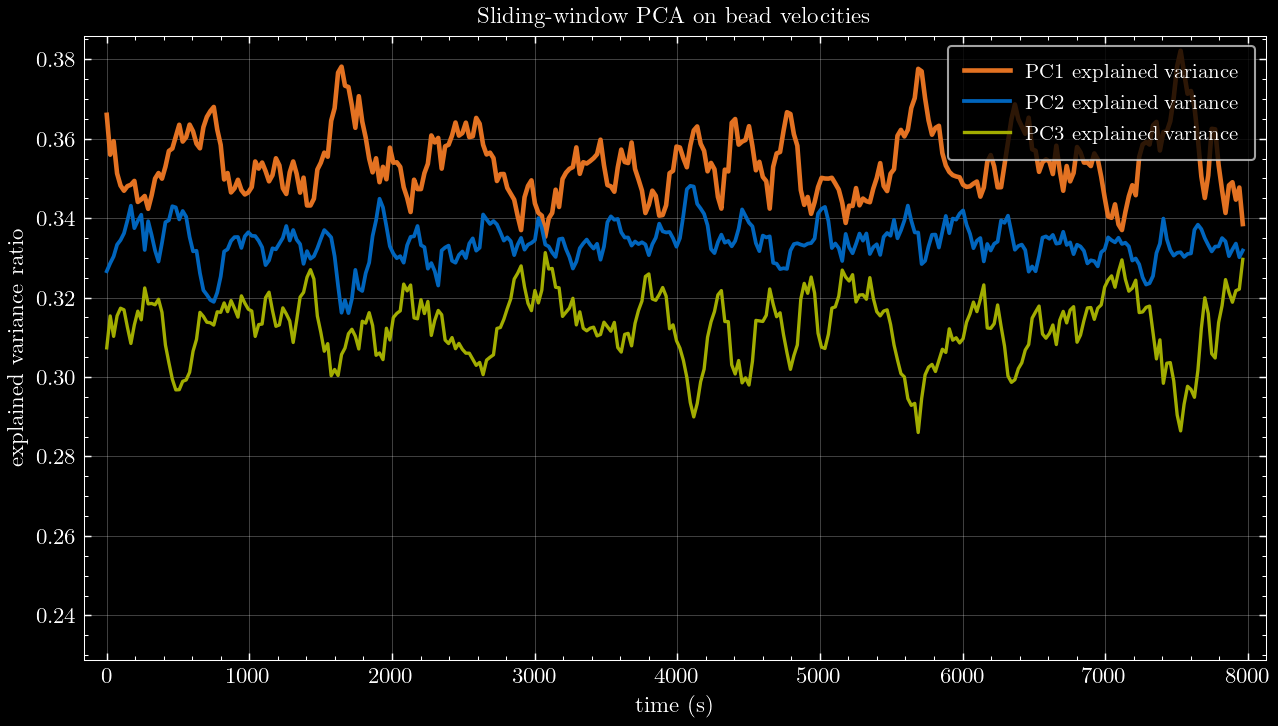

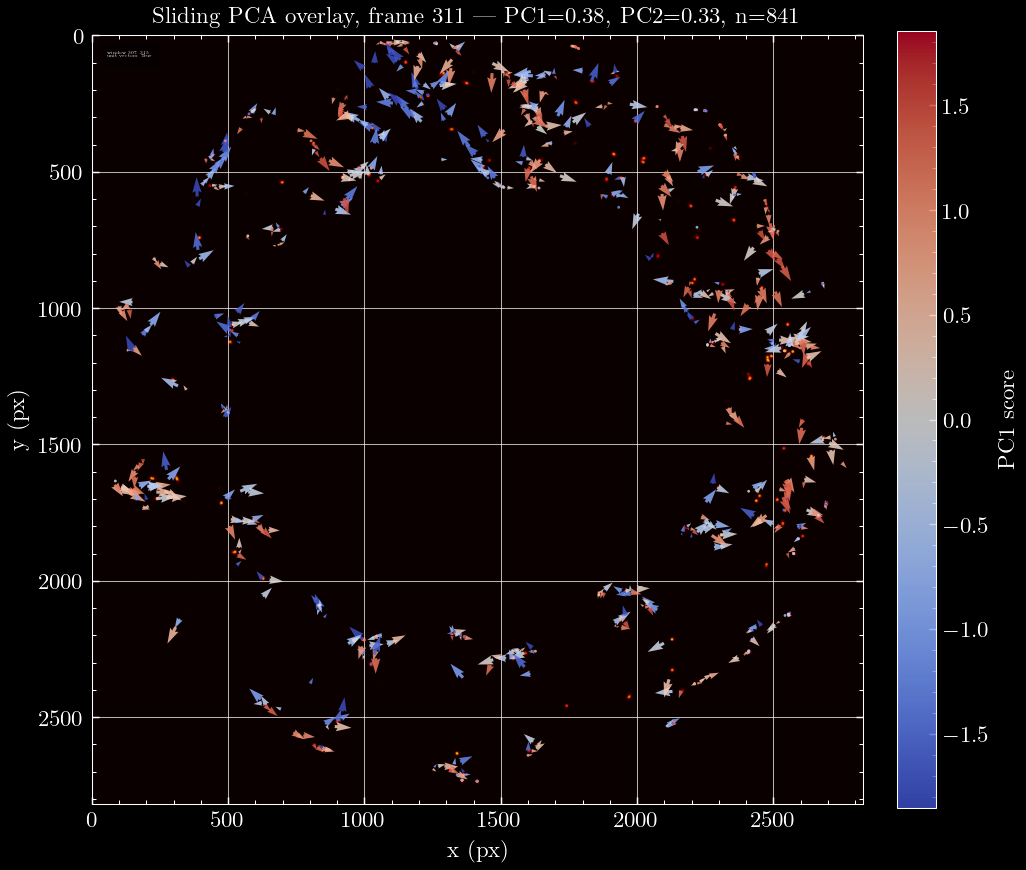

Saved sliding PCA summary to data/AMF_095_002__C640_C470/derived/bead_velocity_sliding_pca_summary.parquet
Saved sliding PCA scores to data/AMF_095_002__C640_C470/derived/bead_velocity_sliding_pca_scores.parquet
Representative PCA frame: 311
Sliding PCA window length (frames): 9
Using unit vectors: True


In [26]:
from analysis_pipeline.io_dataset import load_dataset_state
from matplotlib.colors import Normalize

if '_apply_data_limits' not in globals():
    def _apply_data_limits(ax, x, y, xpad=0.02, ypad=0.08):
        x_arr = np.asarray(x, dtype=float)
        y_arr = np.asarray(y, dtype=float)

        x_finite = x_arr[np.isfinite(x_arr)]
        y_finite = y_arr[np.isfinite(y_arr)]

        if x_finite.size > 0:
            x_min = float(np.min(x_finite))
            x_max = float(np.max(x_finite))
            if x_min == x_max:
                dx = 1.0 if x_min == 0 else abs(x_min) * 0.05
                x_min -= dx
                x_max += dx
            else:
                dx = (x_max - x_min) * float(xpad)
                x_min -= dx
                x_max += dx
            ax.set_xlim(x_min, x_max)

        if y_finite.size > 0:
            y_min = float(np.min(y_finite))
            y_max = float(np.max(y_finite))
            if y_min == y_max:
                dy = 1.0 if y_min == 0 else abs(y_min) * 0.1
                y_min -= dy
                y_max += dy
            else:
                dy = (y_max - y_min) * float(ypad)
                y_min -= dy
                y_max += dy
            ax.set_ylim(y_min, y_max)

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if 'plot_dir' not in globals():
    plot_dir = Path('plots') / dataset_id / str(config['dataset'].get('variation', ''))
    plot_dir.mkdir(parents=True, exist_ok=True)

if 'derived_dir' not in globals():
    derived_dir = Path('data') / dataset_id / 'derived'
    derived_dir.mkdir(parents=True, exist_ok=True)

state_for_pca = (
    globals().get('data_state')
    or globals().get('state_for_autocorr')
    or (globals().get('autocorr_out') or {}).get('state')
    or (globals().get('bead_out') or {}).get('state')
    or load_dataset_state(config['dataset'], verbose=True)
)

tracks_vel_cols = None
if {'vx_um_s', 'vy_um_s', 'vz_um_s'}.issubset(tracks_vel_df.columns):
    tracks_vel_cols = ['vx_um_s', 'vy_um_s', 'vz_um_s']
elif {'vx', 'vy', 'vz'}.issubset(tracks_vel_df.columns):
    tracks_vel_cols = ['vx', 'vy', 'vz']

if tracks_vel_cols is None or len(tracks_vel_df) == 0:
    print('No velocity vectors available for sliding PCA')
else:
    pca_cfg = config.get('beads', {})
    pca_window_frames = int(pca_cfg.get('pca_window_frames', 9))
    if pca_window_frames < 3:
        pca_window_frames = 3
    if pca_window_frames % 2 == 0:
        pca_window_frames += 1
    pca_min_vectors = int(pca_cfg.get('pca_min_vectors', 30))
    pca_window_step = max(1, int(pca_cfg.get('pca_window_step', 1)))
    pca_max_vectors_plot = int(pca_cfg.get('pca_max_vectors_plot', 3000))
    pca_use_unit_vectors = bool(pca_cfg.get('pca_use_unit_vectors', True))

    unique_frames = np.array(sorted(tracks_vel_df['frame'].dropna().astype(int).unique()), dtype=int)
    if unique_frames.size == 0:
        print('No frame indices available for sliding PCA')
    else:
        half_window = pca_window_frames // 2
        summary_rows = []
        score_tables = []

        for center_frame in unique_frames[::pca_window_step]:
            lo = int(center_frame - half_window)
            hi = int(center_frame + half_window)
            window_df = tracks_vel_df[(tracks_vel_df['frame'] >= lo) & (tracks_vel_df['frame'] <= hi)].copy()
            if len(window_df) == 0:
                continue

            vectors = window_df[tracks_vel_cols].to_numpy(dtype=float)
            finite = np.all(np.isfinite(vectors), axis=1)
            vectors = vectors[finite]
            window_df = window_df.loc[finite].copy()
            if len(vectors) == 0:
                continue

            if pca_use_unit_vectors:
                norms = np.linalg.norm(vectors, axis=1)
                good = norms > 0
                vectors = vectors[good] / norms[good][:, None]
                window_df = window_df.loc[good].copy()

            n_vectors = int(len(vectors))
            if n_vectors < pca_min_vectors:
                continue

            raw_mean = vectors.mean(axis=0)
            centered = vectors - raw_mean
            scale = centered.std(axis=0, ddof=0)
            scale[scale == 0] = 1.0
            scaled = centered / scale

            _, singular_values, vt = np.linalg.svd(scaled, full_matrices=False)
            explained_var = (singular_values ** 2) / max(1, n_vectors - 1)
            explained_ratio = explained_var / explained_var.sum() if explained_var.sum() > 0 else np.zeros_like(explained_var)
            components = vt.copy()
            scores = scaled @ components.T

            if np.dot(components[0], raw_mean) < 0:
                components[0] *= -1.0
                scores[:, 0] *= -1.0

            score_tables.append(
                window_df.assign(
                    center_frame=int(center_frame),
                    window_lo=int(lo),
                    window_hi=int(hi),
                    pc1_score=scores[:, 0],
                    pc2_score=scores[:, 1] if scores.shape[1] > 1 else np.nan,
                    pc3_score=scores[:, 2] if scores.shape[1] > 2 else np.nan,
                )
            )
            summary_rows.append(
                {
                    'center_frame': int(center_frame),
                    'window_lo': int(lo),
                    'window_hi': int(hi),
                    'time_s': float(center_frame) / float(state_for_pca['calibration']['fps']) if state_for_pca['calibration'].get('fps') else float(center_frame),
                    'n_vectors': n_vectors,
                    'use_unit_vectors': bool(pca_use_unit_vectors),
                    'pc1_var_ratio': float(explained_ratio[0]) if explained_ratio.size > 0 else np.nan,
                    'pc2_var_ratio': float(explained_ratio[1]) if explained_ratio.size > 1 else np.nan,
                    'pc3_var_ratio': float(explained_ratio[2]) if explained_ratio.size > 2 else np.nan,
                    'pc1_loading_vx': float(components[0, 0]) if components.shape[1] > 0 else np.nan,
                    'pc1_loading_vy': float(components[0, 1]) if components.shape[1] > 1 else np.nan,
                    'pc1_loading_vz': float(components[0, 2]) if components.shape[1] > 2 else np.nan,
                    'pc2_loading_vx': float(components[1, 0]) if components.shape[0] > 1 and components.shape[1] > 0 else np.nan,
                    'pc2_loading_vy': float(components[1, 1]) if components.shape[0] > 1 and components.shape[1] > 1 else np.nan,
                    'pc2_loading_vz': float(components[1, 2]) if components.shape[0] > 1 and components.shape[1] > 2 else np.nan,
                }
            )

        pca_summary_df = pd.DataFrame(summary_rows).sort_values('center_frame').reset_index(drop=True)
        pca_scores_df = pd.concat(score_tables, ignore_index=True) if score_tables else pd.DataFrame()

        if pca_summary_df.empty:
            print('No sliding-window PCA windows had enough finite vectors')
        else:
            pca_summary_path = derived_dir / 'bead_velocity_sliding_pca_summary.parquet'
            pca_scores_path = derived_dir / 'bead_velocity_sliding_pca_scores.parquet'
            pca_summary_df.to_parquet(pca_summary_path, index=False)
            if len(pca_scores_df):
                pca_scores_df.to_parquet(pca_scores_path, index=False)

            fig_pca, ax_pca = plt.subplots(figsize=(8.5, 4.8), dpi=150)
            time_axis = pca_summary_df['time_s'].to_numpy(dtype=float)
            ax_pca.plot(time_axis, pca_summary_df['pc1_var_ratio'], color=tum_colors[0], lw=2.2, label='PC1 explained variance')
            ax_pca.plot(time_axis, pca_summary_df['pc2_var_ratio'], color=tum_colors[1], lw=1.8, label='PC2 explained variance')
            ax_pca.plot(time_axis, pca_summary_df['pc3_var_ratio'], color=tum_colors[2], lw=1.6, label='PC3 explained variance')
            ax_pca.set_xlabel('time (s)')
            ax_pca.set_ylabel('explained variance ratio')
            ax_pca.set_title('Sliding-window PCA on bead velocities')
            ax_pca.grid(True, alpha=0.25)
            ax_pca.legend(loc='upper right', frameon=True, **_legend_scale(fig_pca))
            _apply_data_limits(ax_pca, time_axis, pca_summary_df['pc1_var_ratio'])
            ax_pca.set_ylim(pca_summary_df['pc3_var_ratio'].min() * 0.8, None)
            plt.tight_layout()
            plt.show()

            _save_dual_pdf(fig_pca, f'{dataset_id}_sliding_pca_variance')

            def _pca_variance_white(ax):
                ax.plot(time_axis, pca_summary_df['pc1_var_ratio'], color=tum_colors[0], lw=2.2, label='PC1 explained variance')
                ax.plot(time_axis, pca_summary_df['pc2_var_ratio'], color=tum_colors[1], lw=1.8, label='PC2 explained variance')
                ax.plot(time_axis, pca_summary_df['pc3_var_ratio'], color=tum_colors[2], lw=1.6, label='PC3 explained variance')
                ax.set_xlabel('time (s)')
                ax.set_ylabel('explained variance ratio')
                ax.grid(True, alpha=0.25)
                ax.legend(loc='upper right', frameon=True, **_legend_scale(fig_pca))
                _apply_data_limits(ax, time_axis, pca_summary_df['pc1_var_ratio'])

            _save_dual_replot(f'{dataset_id}_sliding_pca_variance', _pca_variance_white)

            rep_row = pca_summary_df.sort_values(['pc1_var_ratio', 'n_vectors'], ascending=[False, False]).iloc[0]
            rep_center = int(rep_row['center_frame'])
            rep_window_df = pca_scores_df[pca_scores_df['center_frame'] == rep_center].copy() if len(pca_scores_df) else pd.DataFrame()
            if len(rep_window_df) == 0:
                print('Representative PCA window is empty')
            else:
                if len(rep_window_df) > pca_max_vectors_plot:
                    rep_window_df = rep_window_df.sample(n=pca_max_vectors_plot, random_state=0).sort_values('pc1_score')

                bead_channel = int(config['beads'].get('channel_to_use', 1))
                frame_2d = _frame_to_2d_projection(state_for_pca['images'], rep_center, bead_channel)
                px_per_micron = float(state_for_pca['calibration']['px_per_micron'])
                fps = float(state_for_pca['calibration'].get('fps', config.get('dataset', {}).get('fps', 1.0)) or 1.0)
                dt_s = 1.0 / fps if fps > 0 else 1.0
                arrow_scale = 2.0
                vx_um_s = rep_window_df[tracks_vel_cols[0]].to_numpy(dtype=float)
                vy_um_s = rep_window_df[tracks_vel_cols[1]].to_numpy(dtype=float)
                x_px = rep_window_df['x_um'].to_numpy(dtype=float) * px_per_micron if 'x_um' in rep_window_df.columns else rep_window_df['x'].to_numpy(dtype=float)
                y_px = rep_window_df['y_um'].to_numpy(dtype=float) * px_per_micron if 'y_um' in rep_window_df.columns else rep_window_df['y'].to_numpy(dtype=float)
                dx_px = vx_um_s * dt_s * px_per_micron * arrow_scale
                dy_px = vy_um_s * dt_s * px_per_micron * arrow_scale
                pc1_scores = rep_window_df['pc1_score'].to_numpy(dtype=float)
                score_limit = float(np.nanpercentile(np.abs(pc1_scores), 95)) if np.any(np.isfinite(pc1_scores)) else 1.0
                if not np.isfinite(score_limit) or score_limit <= 0:
                    score_limit = 1.0
                score_norm = Normalize(vmin=-score_limit, vmax=score_limit)

                fig_overlay, ax_overlay = plt.subplots(figsize=(6.8, 6.3), dpi=150)
                ax_overlay.imshow(frame_2d, cmap='hot', alpha=0.85)
                quiver = ax_overlay.quiver(
                    x_px,
                    y_px,
                    dx_px,
                    dy_px,
                    pc1_scores,
                    cmap='coolwarm',
                    norm=score_norm,
                    angles='xy',
                    scale_units='xy',
                    scale=1,
                    width=0.004,
                    alpha=0.85,
                    pivot='tail',
                    zorder=3,
                )
                colorbar = fig_overlay.colorbar(quiver, ax=ax_overlay, fraction=0.046, pad=0.04)
                colorbar.set_label('PC1 score')
                ax_overlay.set_title(
                    f'Sliding PCA overlay, frame {rep_center} | '
                    f'PC1={rep_row["pc1_var_ratio"]:.2f}, PC2={rep_row["pc2_var_ratio"]:.2f}, n={rep_row["n_vectors"]}'
                )
                ax_overlay.set_xlabel('x (px)')
                ax_overlay.set_ylabel('y (px)')
                ax_overlay.set_aspect('equal')
                ax_overlay.text(
                    0.02,
                    0.98,
                    f'window {int(rep_row["window_lo"])}..{int(rep_row["window_hi"])}\nunit vectors: {pca_use_unit_vectors}',
                    transform=ax_overlay.transAxes,
                    ha='left',
                    va='top',
                    color='white',
                    bbox=dict(facecolor='black', alpha=0.35, edgecolor='none'),
                )
                plt.tight_layout()
                plt.show()

                _save_dual_pdf(fig_overlay, f'{dataset_id}_sliding_pca_overlay')

                def _pca_overlay_white(ax):
                    ax.imshow(frame_2d, cmap='hot', alpha=0.85)
                    q = ax.quiver(
                        x_px,
                        y_px,
                        dx_px,
                        dy_px,
                        pc1_scores,
                        cmap='coolwarm',
                        norm=score_norm,
                        angles='xy',
                        scale_units='xy',
                        scale=1,
                        width=0.004,
                        alpha=0.85,
                        pivot='tail',
                        zorder=3,
                    )
                    ax.set_xlabel('x (px)')
                    ax.set_ylabel('y (px)')
                    ax.set_aspect('equal')
                    ax.set_title(
                        f'Sliding PCA overlay, frame {rep_center} | '
                        f'PC1={rep_row["pc1_var_ratio"]:.2f}, PC2={rep_row["pc2_var_ratio"]:.2f}, n={rep_row["n_vectors"]}'
                    )
                    ax.text(
                        0.02,
                        0.98,
                        f'window {int(rep_row["window_lo"])}..{int(rep_row["window_hi"])}\nunit vectors: {pca_use_unit_vectors}',
                        transform=ax.transAxes,
                        ha='left',
                        va='top',
                        color='black',
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='0.4'),
                    )
                    ax.grid(False)
                    ax.figure.colorbar(q, ax=ax, fraction=0.046, pad=0.04)

                _save_dual_replot(f'{dataset_id}_sliding_pca_overlay', _pca_overlay_white)

            print('Saved sliding PCA summary to', pca_summary_path)
            if len(pca_scores_df):
                print('Saved sliding PCA scores to', pca_scores_path)
            print('Representative PCA frame:', rep_center)
            print('Sliding PCA window length (frames):', pca_window_frames)
            print('Using unit vectors:', pca_use_unit_vectors)


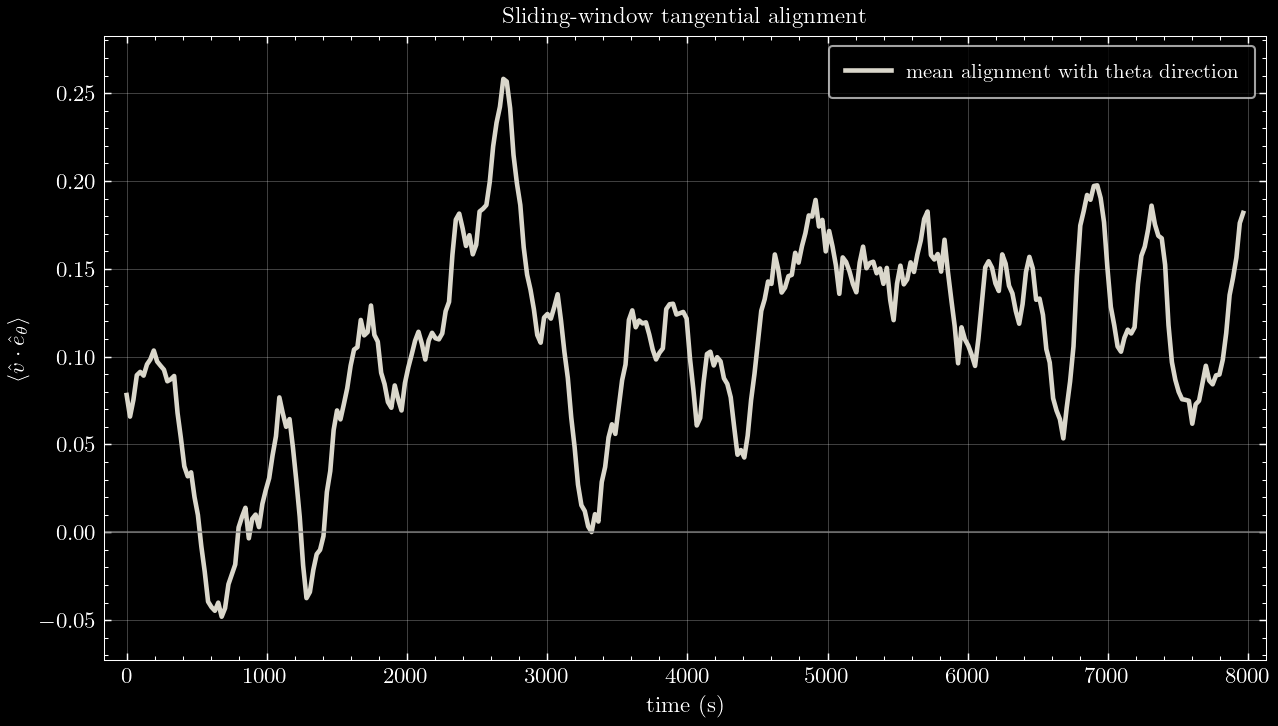

Saved theta-alignment plot to plots/AMF_095_002__C640_C470/AMF_095_002__C640_C470_sliding_theta_alignment_black.pdf
Theta-alignment windows: 330
Mean theta alignment: 0.10610299729403808
Median theta alignment: 0.24127845451736626


In [39]:
if 'pca_scores_df' not in globals() or pca_scores_df is None or len(pca_scores_df) == 0:
    print('No sliding PCA scores available for theta-alignment plot')
else:
    beads_cfg = config.get('beads', {})
    px_per_micron = float(state_for_pca['calibration']['px_per_micron'])
    origin_x_um = beads_cfg.get('origin_x_um', None)
    origin_y_um = beads_cfg.get('origin_y_um', None)
    if origin_x_um is None:
        origin_x_um = (float(state_for_pca['dims']['X']) - 1.0) / (2.0 * px_per_micron)
    if origin_y_um is None:
        origin_y_um = (float(state_for_pca['dims']['Y']) - 1.0) / (2.0 * px_per_micron)

    if {'x_um', 'y_um'}.issubset(pca_scores_df.columns):
        x_um = pca_scores_df['x_um'].to_numpy(dtype=float)
        y_um = pca_scores_df['y_um'].to_numpy(dtype=float)
    elif {'x', 'y'}.issubset(pca_scores_df.columns):
        x_um = pca_scores_df['x'].to_numpy(dtype=float) / px_per_micron
        y_um = pca_scores_df['y'].to_numpy(dtype=float) / px_per_micron
    else:
        x_um = np.array([])
        y_um = np.array([])

    if {'vx_um_s', 'vy_um_s'}.issubset(pca_scores_df.columns):
        vx_um_s = pca_scores_df['vx_um_s'].to_numpy(dtype=float)
        vy_um_s = pca_scores_df['vy_um_s'].to_numpy(dtype=float)
    elif {'vx', 'vy'}.issubset(pca_scores_df.columns):
        vx_um_s = pca_scores_df['vx'].to_numpy(dtype=float)
        vy_um_s = pca_scores_df['vy'].to_numpy(dtype=float)
    else:
        vx_um_s = np.array([])
        vy_um_s = np.array([])

    if x_um.size == 0 or vx_um_s.size == 0:
        print('Velocity table is missing x/y or vx/vy columns needed for theta alignment')
    else:
        finite = (
            np.isfinite(x_um)
            & np.isfinite(y_um)
            & np.isfinite(vx_um_s)
            & np.isfinite(vy_um_s)
        )
        x_um = x_um[finite]
        y_um = y_um[finite]
        vx_um_s = vx_um_s[finite]
        vy_um_s = vy_um_s[finite]
        pca_scores_align_df = pca_scores_df.loc[finite].copy()
        if 'time_s' not in pca_scores_align_df.columns and 'center_frame' in pca_scores_align_df.columns and 'time_s' in pca_summary_df.columns:
            center_time_map = pca_summary_df.set_index('center_frame')['time_s'].to_dict()
            pca_scores_align_df['time_s'] = pca_scores_align_df['center_frame'].map(center_time_map)

        speed_xy = np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
        moving = speed_xy > 0
        x_um = x_um[moving]
        y_um = y_um[moving]
        vx_um_s = vx_um_s[moving]
        vy_um_s = vy_um_s[moving]
        pca_scores_align_df = pca_scores_align_df.loc[moving].copy()

        theta_rad = np.arctan2(y_um - float(origin_y_um), x_um - float(origin_x_um))
        theta_hat_x = -np.sin(theta_rad)
        theta_hat_y = np.cos(theta_rad)
        v_hat_x = vx_um_s / np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
        v_hat_y = vy_um_s / np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
        theta_alignment = v_hat_x * theta_hat_x + v_hat_y * theta_hat_y

        pca_scores_align_df['theta_alignment'] = theta_alignment
        theta_alignment_df = (
            pca_scores_align_df
            .groupby('center_frame', sort=True)
            .agg(
                time_s=('time_s', 'first'),
                mean_theta_alignment=('theta_alignment', 'mean'),
                median_theta_alignment=('theta_alignment', 'median'),
                positive_theta_fraction=('theta_alignment', lambda s: float(np.mean(np.asarray(s) > 0))),
                n_vectors=('theta_alignment', 'size'),
            )
            .reset_index()
            .sort_values('time_s')
        )

        fig_theta, ax_theta = plt.subplots(figsize=(8.5, 4.8), dpi=150)
        time_axis = theta_alignment_df['time_s'].to_numpy(dtype=float)
        ax_theta.plot(
            time_axis,
            theta_alignment_df['mean_theta_alignment'],
            color=tum_colors[4],
            lw=2.2,
            label='mean alignment with theta direction',
        )
        ax_theta.axhline(0.0, color='gray', lw=1.0, alpha=0.7)
        ax_theta.set_xlabel('time (s)')
        ax_theta.set_ylabel(r'$\langle \hat{v} \cdot \hat{e}_\theta \rangle$')
        ax_theta.set_title('Sliding-window tangential alignment')
        ax_theta.grid(True, alpha=0.25)
        ax_theta.legend(loc='upper right', frameon=True, **_legend_scale(fig_theta))
        _apply_data_limits(ax_theta, time_axis, theta_alignment_df['mean_theta_alignment'])
        plt.tight_layout()
        plt.show()

        _save_dual_pdf(fig_theta, f'{dataset_id}_sliding_theta_alignment')

        def _theta_alignment_white(ax):
            ax.plot(
                time_axis,
                theta_alignment_df['mean_theta_alignment'],
                color=tum_colors[4],
                lw=2.2,
                label='mean alignment with theta direction',
            )
            ax.axhline(0.0, color='gray', lw=1.0, alpha=0.7)
            ax.set_xlabel('time (s)')
            ax.set_ylabel(r'$\langle \hat{v} \cdot \hat{e}_\theta \rangle$')
            ax.grid(True, alpha=0.25)
            ax.legend(loc='upper right', frameon=True, **_legend_scale(fig_theta))
            _apply_data_limits(ax, time_axis, theta_alignment_df['mean_theta_alignment'])

        _save_dual_replot(f'{dataset_id}_sliding_theta_alignment', _theta_alignment_white)

        print('Saved theta-alignment plot to', plot_dir / f'{dataset_id}_sliding_theta_alignment_black.pdf')
        print('Theta-alignment windows:', len(theta_alignment_df))
        print('Mean theta alignment:', float(theta_alignment_df['mean_theta_alignment'].mean()))
        print('Median theta alignment:', float(theta_alignment_df['median_theta_alignment'].mean()))


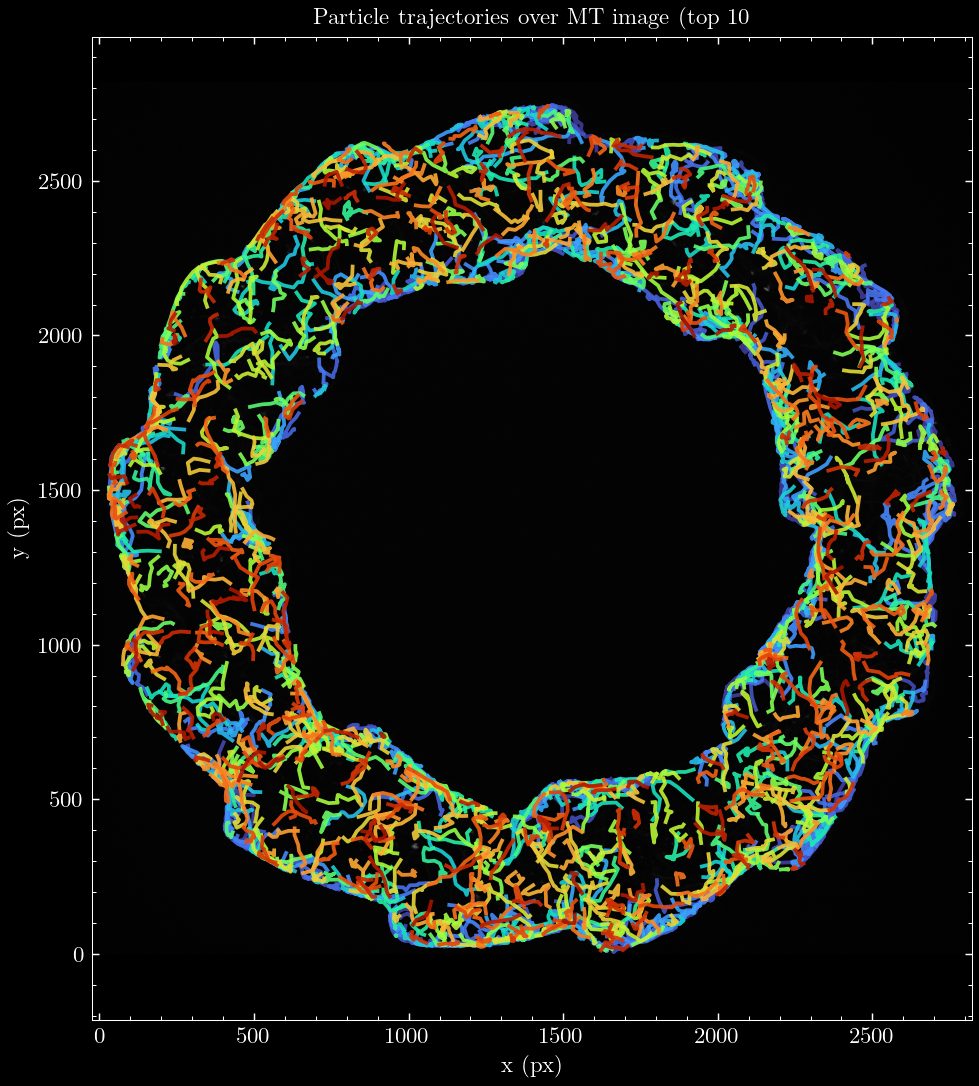

Plotted all particle trajectories: 1531
Kept the longest tracks for the top 11 % of particles
Saved trajectory overlay to plots/AMF_095_002__C640_C470/AMF_095_002__C640_C470_all_particle_trajectories_over_mt_black.pdf


In [47]:
if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0 or 'particle' not in tracks_vel_df.columns or not {'x_um', 'y_um'}.issubset(tracks_vel_df.columns):
    print('No particle trajectories available for plotting')
else:
    if 'data_state' not in globals() or data_state is None:
        data_state = load_dataset_state(config['dataset'], verbose=True)

    bead_channel = int(config['beads'].get('channel_to_use', 1))
    mt_channel = 0 if bead_channel != 0 else 1
    frame_to_show = 0
    mt_image = data_state['images'][frame_to_show, mt_channel]
    mt_image = mt_image.compute() if hasattr(mt_image, 'compute') else mt_image
    mt_image = np.asarray(mt_image, dtype=float)
    if mt_image.ndim == 3:
        mt_image = mt_image.max(axis=0)
    elif mt_image.ndim != 2:
        raise ValueError(f'Unexpected mt image shape: {mt_image.shape}')

    trajectory_counts = tracks_vel_df.groupby('particle').size().sort_values(ascending=False)
    n_particles_total = int(len(trajectory_counts))
    n_particles_keep = max(1, int(np.ceil(n_particles_total * 0.10)))
    selected_particles = trajectory_counts.index[:n_particles_keep].tolist()
    traj_df = tracks_vel_df[tracks_vel_df['particle'].isin(selected_particles)].copy()
    traj_df = traj_df.sort_values(['particle', 'frame'])

    fig_traj, ax_traj = plt.subplots(figsize=(8.4, 7.2), dpi=150)
    ax_traj.imshow(mt_image, cmap='gray', alpha=0.95)

    particles = selected_particles
    colors = plt.get_cmap('turbo')(np.linspace(0.05, 0.95, max(len(particles), 2))) if len(particles) > 1 else np.array([tum_colors[0]])

    for idx, particle_id in enumerate(particles):
        particle_df = traj_df[traj_df['particle'] == particle_id].sort_values('frame')
        if len(particle_df) == 0:
            continue

        x_vals = particle_df['x_um'].to_numpy(dtype=float) * px_per_micron
        y_vals = particle_df['y_um'].to_numpy(dtype=float) * px_per_micron
        valid = np.isfinite(x_vals) & np.isfinite(y_vals)
        x_vals = x_vals[valid]
        y_vals = y_vals[valid]
        if len(x_vals) < 2:
            continue

        color = colors[idx % len(colors)]
        ax_traj.plot(x_vals, y_vals, lw=1.8, color=color, alpha=0.9, zorder=3)

    ax_traj.set_xlabel('x (px)')
    ax_traj.set_ylabel('y (px)')
    ax_traj.set_title(f'Particle trajectories over MT image (top {int(np.round(100 * n_particles_keep / n_particles_total))}% longest tracks)')
    ax_traj.set_aspect('equal', adjustable='box')
    ax_traj.grid(False)
    _apply_data_limits(ax_traj, traj_df['x_um'] * px_per_micron, traj_df['y_um'] * px_per_micron)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_traj, f'{dataset_id}_all_particle_trajectories_over_mt')

    def _trajectories_white(ax):
        ax.imshow(mt_image, cmap='gray', alpha=0.95)
        for idx, particle_id in enumerate(particles):
            particle_df = traj_df[traj_df['particle'] == particle_id].sort_values('frame')
            if len(particle_df) == 0:
                continue
            x_vals = particle_df['x_um'].to_numpy(dtype=float) * px_per_micron
            y_vals = particle_df['y_um'].to_numpy(dtype=float) * px_per_micron
            valid = np.isfinite(x_vals) & np.isfinite(y_vals)
            x_vals = x_vals[valid]
            y_vals = y_vals[valid]
            if len(x_vals) < 2:
                continue
            color = colors[idx % len(colors)]
            ax.plot(x_vals, y_vals, lw=1.8, color=color, alpha=0.9)
        ax.set_xlabel('x (px)')
        ax.set_ylabel('y (px)')
        ax.set_aspect('equal', adjustable='box')
        ax.grid(False)
        _apply_data_limits(ax, traj_df['x_um'] * px_per_micron, traj_df['y_um'] * px_per_micron)

    _save_dual_replot(f'{dataset_id}_all_particle_trajectories_over_mt', _trajectories_white)

    print('Plotted all particle trajectories:', len(particles))
    print('Kept the longest tracks for the top', int(np.ceil(100 * n_particles_keep / n_particles_total)), '% of particles')
    print('Saved trajectory overlay to', plot_dir / f'{dataset_id}_all_particle_trajectories_over_mt_black.pdf')

## 10.3. Trajectory Alignment with Theta vs Radius

This subsection measures how strongly the selected trajectories align with the tangential theta direction as a function of radius.

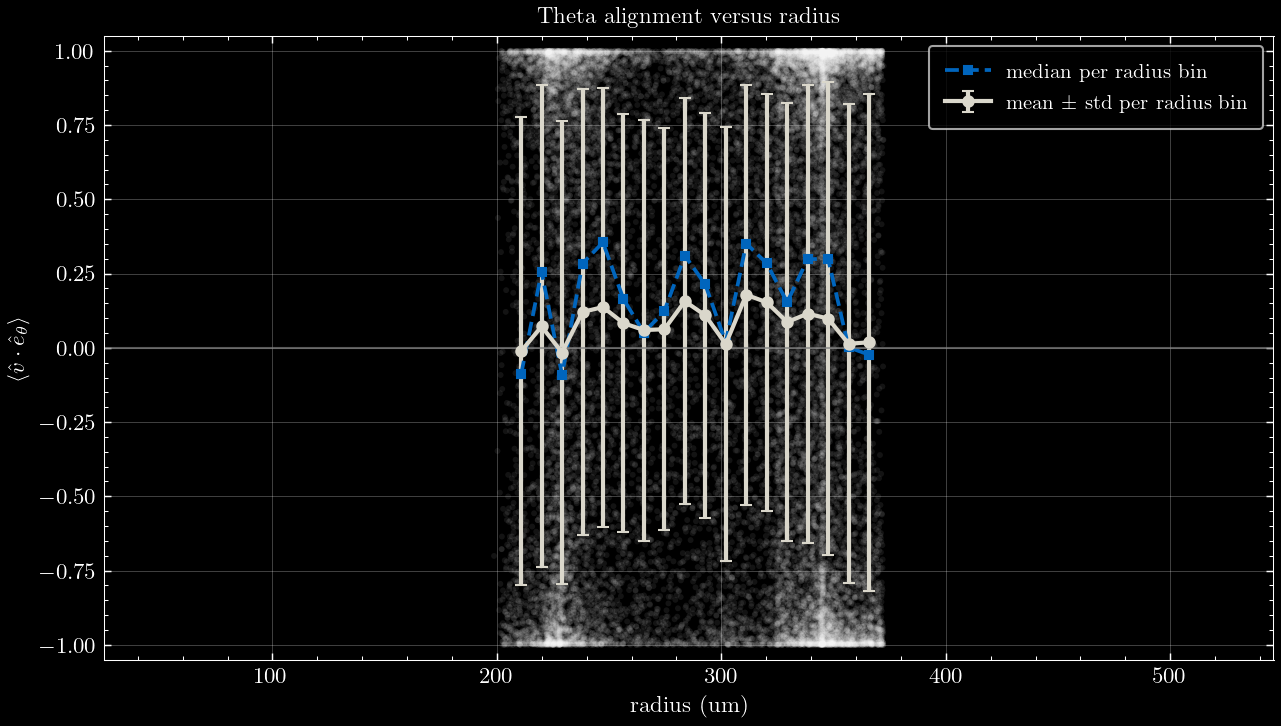

,radius_bin,mean_alignment,median_alignment,std_alignment,n_points,radius_bin_center_um
0,"(206.23, 215.349]",-0.011738,-0.089848,0.787778,574,210.7895
1,"(215.349, 224.467]",0.071984,0.256646,0.811095,1164,219.9080
2,"(224.467, 233.584]",-0.015917,-0.091196,0.778325,1824,229.0255
3,"(233.584, 242.702]",0.120668,0.283715,0.751332,1206,238.1430
4,"(242.702, 251.82]",0.137099,0.354831,0.739012,803,247.2610
5,"(251.82, 260.938]",0.083069,0.163927,0.704666,523,256.3790
6,"(260.938, 270.056]",0.059666,0.051350,0.708605,477,265.4970
7,"(270.056, 279.173]",0.062490,0.123592,0.676620,397,274.6145
8,"(279.173, 288.291]",0.156602,0.310425,0.683572,472,283.7320
9,"(288.291, 297.409]",0.109307,0.213080,0.681537,526,292.8500


Theta-alignment radius points: 19312
Theta-alignment radius bins: 18
Mean theta alignment: 0.07507630418274434
Median theta alignment: 0.18177331605526598


In [48]:
from analysis_pipeline.io_dataset import load_dataset_state

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0 or 'particle' not in tracks_vel_df.columns or not {'x_um', 'y_um'}.issubset(tracks_vel_df.columns):
    print('No particle trajectories available for radius-alignment plotting')
else:
    if 'data_state' not in globals() or data_state is None:
        data_state = load_dataset_state(config['dataset'], verbose=True)

    px_per_micron = float(data_state['calibration']['px_per_micron'])
    fps = float(data_state['calibration'].get('fps', config.get('dataset', {}).get('fps', 1.0)) or 1.0)
    origin_x_um = config['beads'].get('origin_x_um', None)
    origin_y_um = config['beads'].get('origin_y_um', None)
    if origin_x_um is None:
        origin_x_um = (float(data_state['dims']['X']) - 1.0) / (2.0 * px_per_micron)
    if origin_y_um is None:
        origin_y_um = (float(data_state['dims']['Y']) - 1.0) / (2.0 * px_per_micron)

    trajectory_counts = tracks_vel_df.groupby('particle').size().sort_values(ascending=False)
    n_particles_total = int(len(trajectory_counts))
    n_particles_keep = max(1, int(np.ceil(n_particles_total * 0.10)))
    selected_particles = trajectory_counts.index[:n_particles_keep].tolist()
    traj_df = tracks_vel_df[tracks_vel_df['particle'].isin(selected_particles)].copy()
    traj_df = traj_df.sort_values(['particle', 'frame'])

    if not {'vx_um_s', 'vy_um_s'}.issubset(traj_df.columns):
        print('Trajectory table is missing velocity components required for theta alignment')
    else:
        x_um = traj_df['x_um'].to_numpy(dtype=float)
        y_um = traj_df['y_um'].to_numpy(dtype=float)
        vx_um_s = traj_df['vx_um_s'].to_numpy(dtype=float)
        vy_um_s = traj_df['vy_um_s'].to_numpy(dtype=float)
        finite = np.isfinite(x_um) & np.isfinite(y_um) & np.isfinite(vx_um_s) & np.isfinite(vy_um_s)
        x_um = x_um[finite]
        y_um = y_um[finite]
        vx_um_s = vx_um_s[finite]
        vy_um_s = vy_um_s[finite]

        speed_xy = np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
        moving = speed_xy > 0
        x_um = x_um[moving]
        y_um = y_um[moving]
        vx_um_s = vx_um_s[moving]
        vy_um_s = vy_um_s[moving]

        if len(x_um) == 0:
            print('No moving trajectories available for theta alignment versus radius')
        else:
            theta_rad = np.arctan2(y_um - float(origin_y_um), x_um - float(origin_x_um))
            theta_hat_x = -np.sin(theta_rad)
            theta_hat_y = np.cos(theta_rad)
            v_hat_x = vx_um_s / np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
            v_hat_y = vy_um_s / np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
            theta_alignment = v_hat_x * theta_hat_x + v_hat_y * theta_hat_y
            radius_um = np.sqrt((x_um - float(origin_x_um)) ** 2 + (y_um - float(origin_y_um)) ** 2)

            radius_alignment_df = pd.DataFrame(
                {
                    'radius_um': radius_um,
                    'theta_alignment': theta_alignment,
                }
            ).replace([np.inf, -np.inf], np.nan).dropna()

            if len(radius_alignment_df) == 0:
                print('No finite values available for theta alignment versus radius')
            else:
                n_bins = min(18, max(8, int(np.ceil(np.sqrt(len(radius_alignment_df))))))
                radius_min = float(np.nanpercentile(radius_alignment_df['radius_um'], 1))
                radius_max = float(np.nanpercentile(radius_alignment_df['radius_um'], 99))
                if not np.isfinite(radius_min) or not np.isfinite(radius_max) or radius_max <= radius_min:
                    radius_min = float(np.nanmin(radius_alignment_df['radius_um']))
                    radius_max = float(np.nanmax(radius_alignment_df['radius_um']))

                if radius_max <= radius_min:
                    print('Radius range is too small to bin')
                else:
                    bin_edges = np.linspace(radius_min, radius_max, n_bins + 1)
                    radius_alignment_df['radius_bin'] = pd.cut(
                        radius_alignment_df['radius_um'],
                        bins=bin_edges,
                        include_lowest=True,
                        duplicates='drop',
                    )
                    radius_alignment_summary = (
                        radius_alignment_df.groupby('radius_bin', observed=True)
                        .agg(
                            mean_alignment=('theta_alignment', 'mean'),
                            median_alignment=('theta_alignment', 'median'),
                            std_alignment=('theta_alignment', 'std'),
                            n_points=('theta_alignment', 'size'),
                        )
                        .reset_index()
                    )
                    radius_alignment_summary['radius_bin_center_um'] = radius_alignment_summary['radius_bin'].apply(lambda interval: float(interval.mid))
                    radius_alignment_summary['std_alignment'] = radius_alignment_summary['std_alignment'].fillna(0.0)
                    radius_alignment_summary = radius_alignment_summary.sort_values('radius_bin_center_um').reset_index(drop=True)

                    fig_radius, ax_radius = plt.subplots(figsize=(8.5, 4.8), dpi=150)
                    ax_radius.scatter(
                        radius_alignment_df['radius_um'],
                        radius_alignment_df['theta_alignment'],
                        s=8,
                        color='white',
                        alpha=0.08,
                        edgecolors='none',
                        rasterized=True,
                    )
                    ax_radius.errorbar(
                        radius_alignment_summary['radius_bin_center_um'],
                        radius_alignment_summary['mean_alignment'],
                        yerr=radius_alignment_summary['std_alignment'],
                        fmt='o-',
                        color=tum_colors[4],
                        ecolor=tum_colors[4],
                        capsize=3,
                        lw=2.0,
                        ms=5,
                        label='mean ± std per radius bin',
                    )
                    ax_radius.plot(
                        radius_alignment_summary['radius_bin_center_um'],
                        radius_alignment_summary['median_alignment'],
                        color=tum_colors[1],
                        lw=1.8,
                        ls='--',
                        marker='s',
                        ms=4,
                        label='median per radius bin',
                    )
                    ax_radius.axhline(0.0, color='gray', lw=1.0, alpha=0.7)
                    ax_radius.set_xlabel('radius (um)')
                    ax_radius.set_ylabel(r'$\langle \hat{v} \cdot \hat{e}_\theta \rangle$')
                    ax_radius.set_title('Theta alignment versus radius')
                    ax_radius.set_ylim(-1.05, 1.05)
                    ax_radius.grid(True, alpha=0.25)
                    ax_radius.legend(loc='upper right', frameon=True, **_legend_scale(fig_radius))
                    plt.tight_layout()
                    plt.show()

                    _save_dual_pdf(fig_radius, f'{dataset_id}_trajectory_theta_alignment_by_radius')

                    def _radius_alignment_white(ax):
                        ax.scatter(
                            radius_alignment_df['radius_um'],
                            radius_alignment_df['theta_alignment'],
                            s=8,
                            color='0.3',
                            alpha=0.12,
                            edgecolors='none',
                            rasterized=True,
                        )
                        ax.errorbar(
                            radius_alignment_summary['radius_bin_center_um'],
                            radius_alignment_summary['mean_alignment'],
                            yerr=radius_alignment_summary['std_alignment'],
                            fmt='o-',
                            color=tum_colors[4],
                            ecolor=tum_colors[4],
                            capsize=3,
                            lw=2.0,
                            ms=5,
                            label='mean ± std per radius bin',
                        )
                        ax.plot(
                            radius_alignment_summary['radius_bin_center_um'],
                            radius_alignment_summary['median_alignment'],
                            color=tum_colors[1],
                            lw=1.8,
                            ls='--',
                            marker='s',
                            ms=4,
                            label='median per radius bin',
                        )
                        ax.axhline(0.0, color='gray', lw=1.0, alpha=0.7)
                        ax.set_xlabel('radius (um)')
                        ax.set_ylabel(r'$\langle \hat{v} \cdot \hat{e}_\theta \rangle$')
                        ax.set_ylim(-1.05, 1.05)
                        ax.grid(True, alpha=0.25)
                        ax.legend(loc='upper right', frameon=True, **_legend_scale(fig_radius))

                    _save_dual_replot(f'{dataset_id}_trajectory_theta_alignment_by_radius', _radius_alignment_white)

                    display(radius_alignment_summary)
                    print('Theta-alignment radius points:', len(radius_alignment_df))
                    print('Theta-alignment radius bins:', len(radius_alignment_summary))
                    print('Mean theta alignment:', float(radius_alignment_df['theta_alignment'].mean()))
                    print('Median theta alignment:', float(radius_alignment_df['theta_alignment'].median()))

## 10.4. Endpoint-Based Angular Speed Distribution

This subsection uses only the 10% longest tracks and estimates the angular speed from each trajectory's start-to-end displacement.

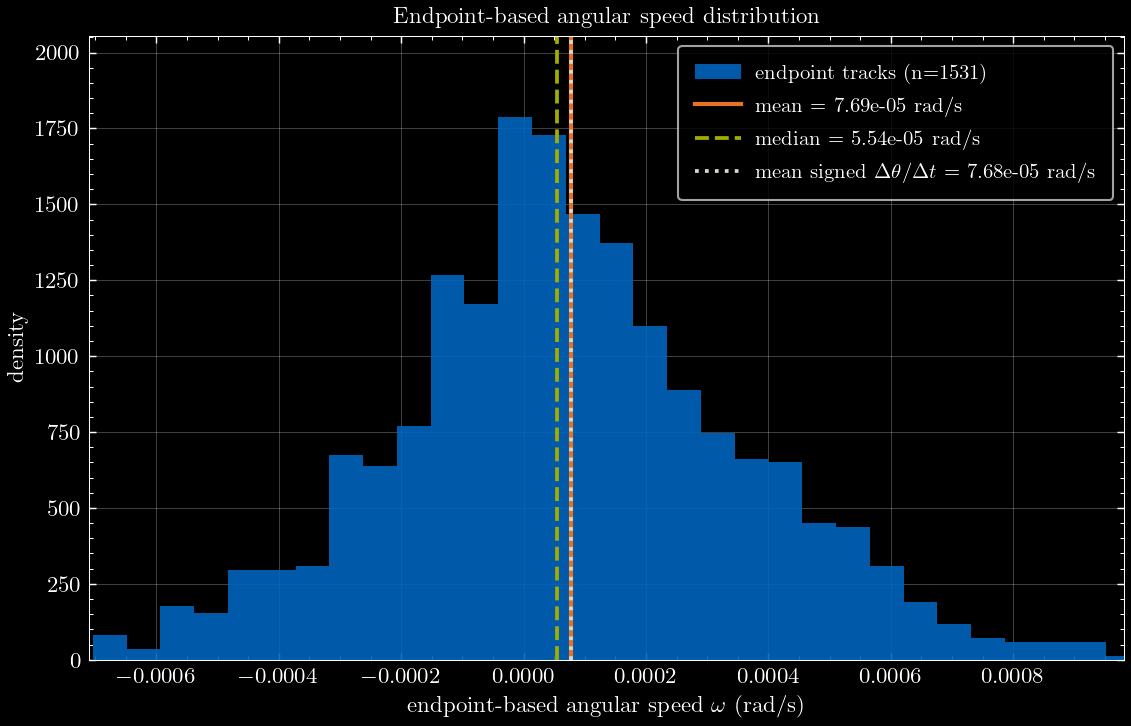

,particle,n_points,start_frame,end_frame,duration_s,trajectory_length_um,radius_mid_um,start_theta_rad,end_theta_rad,signed_angular_displacement_rad,tangential_displacement_um,omega_endpoint_rad_s,mean_angular_speed_from_displacement_rad_s,linear_speed_um_s
0,0,10,0,9,217.890018,37.704385,353.803488,-1.691582,-1.589628,0.101954,36.101923,0.000468,0.000468,0.166668
1,31,63,0,62,1501.020124,10.041511,328.039599,0.402075,0.405300,0.003225,1.057936,0.000002,0.000002,0.003967
2,34,13,0,14,338.940028,45.078826,325.512575,0.660704,0.640456,-0.020248,-6.579936,-0.000060,-0.000060,0.081394
3,35,11,0,10,242.100020,48.371023,238.906562,1.787208,1.762471,-0.024737,-5.880553,-0.000102,-0.000102,0.142007
4,42,20,0,19,459.990038,37.941817,335.762244,-0.585087,-0.533447,0.051640,17.336826,0.000112,0.000112,0.046141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1526,15050,7,323,329,145.260012,30.586274,357.419089,-1.388605,-1.423294,-0.034688,-12.390036,-0.000239,-0.000239,0.160442
1527,15056,7,323,329,145.260012,27.854557,235.807242,0.681857,0.733974,0.052117,12.292260,0.000359,0.000359,0.085030
1528,15057,7,323,329,145.260012,6.061234,365.247783,-0.940512,-0.935254,0.005258,1.920449,0.000036,0.000036,0.015859
1529,15060,7,323,329,145.260012,11.629049,232.050512,1.531156,1.533849,0.002694,0.625015,0.000019,0.000019,0.024962


Endpoint tracks used: 1531
Endpoint angular speed sample size: 1531
Endpoint angular speed mean: 7.686103305335669e-05
Endpoint angular speed median: 5.535872470616296e-05
Endpoint angular speed std: 0.0002902677678449741
Mean signed angular displacement: 0.01824081392273664
Median signed angular displacement: 0.0171580796916162
Mean signed tangential displacement: 5.355199286736421
Median signed tangential displacement: 5.312542685587623
Mean trajectory length: 42.255518736076745
Median trajectory length: 39.108062345857626
Mean signed angular speed from displacement: 7.678764240883145e-05
Longest-track fraction used: 1531 / 15306
Saved endpoint-based angular speed plot to plots/AMF_095_002__C640_C470/AMF_095_002__C640_C470_endpoint_based_angular_speed_distribution_black.pdf


In [52]:
from analysis_pipeline.io_dataset import load_dataset_state

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0 or 'particle' not in tracks_vel_df.columns or not {'x_um', 'y_um'}.issubset(tracks_vel_df.columns):
    print('No particle trajectories available for endpoint-based angular speed plotting')
else:
    if 'data_state' not in globals() or data_state is None:
        data_state = load_dataset_state(config['dataset'], verbose=True)

    px_per_micron = float(data_state['calibration']['px_per_micron'])
    fps = float(data_state['calibration'].get('fps', config.get('dataset', {}).get('fps', 1.0)) or 1.0)
    origin_x_um = config['beads'].get('origin_x_um', None)
    origin_y_um = config['beads'].get('origin_y_um', None)
    if origin_x_um is None:
        origin_x_um = (float(data_state['dims']['X']) - 1.0) / (2.0 * px_per_micron)
    if origin_y_um is None:
        origin_y_um = (float(data_state['dims']['Y']) - 1.0) / (2.0 * px_per_micron)

    trajectory_counts = tracks_vel_df.groupby('particle').size().sort_values(ascending=False)
    n_particles_total = int(len(trajectory_counts))
    n_particles_keep = max(1, int(np.ceil(n_particles_total * 0.10)))
    selected_particles = trajectory_counts.index[:n_particles_keep].tolist()
    traj_df = tracks_vel_df[tracks_vel_df['particle'].isin(selected_particles)].copy()
    traj_df = traj_df.sort_values(['particle', 'frame'])

    endpoint_rows = []
    for particle_id, particle_df in traj_df.groupby('particle', sort=False):
        particle_df = particle_df.sort_values('frame')
        particle_df = particle_df[np.isfinite(particle_df['x_um']) & np.isfinite(particle_df['y_um']) & np.isfinite(particle_df['frame'])]
        if len(particle_df) < 2:
            continue

        start_row = particle_df.iloc[0]
        end_row = particle_df.iloc[-1]
        duration_s = (float(end_row['frame']) - float(start_row['frame'])) / fps if fps > 0 else np.nan
        if not np.isfinite(duration_s) or duration_s <= 0:
            continue

        start_xy = np.array([float(start_row['x_um']), float(start_row['y_um'])], dtype=float)
        end_xy = np.array([float(end_row['x_um']), float(end_row['y_um'])], dtype=float)
        displacement_xy = end_xy - start_xy
        midpoint_xy = 0.5 * (start_xy + end_xy)
        midpoint_radius = float(np.hypot(midpoint_xy[0] - float(origin_x_um), midpoint_xy[1] - float(origin_y_um)))
        if not np.isfinite(midpoint_radius) or midpoint_radius <= 0:
            continue

        start_theta = float(np.arctan2(start_xy[1] - float(origin_y_um), start_xy[0] - float(origin_x_um)))
        end_theta = float(np.arctan2(end_xy[1] - float(origin_y_um), end_xy[0] - float(origin_x_um)))
        signed_angular_displacement_rad = float(np.arctan2(np.sin(end_theta - start_theta), np.cos(end_theta - start_theta)))
        midpoint_theta = float(np.arctan2(midpoint_xy[1] - float(origin_y_um), midpoint_xy[0] - float(origin_x_um)))
        theta_hat_xy = np.array([-np.sin(midpoint_theta), np.cos(midpoint_theta)], dtype=float)
        tangential_displacement_um = float(np.dot(displacement_xy, theta_hat_xy))
        omega_endpoint_rad_s = tangential_displacement_um / (midpoint_radius * duration_s)
        mean_angular_speed_from_displacement_rad_s = signed_angular_displacement_rad / duration_s
        linear_speed_um_s = float(np.linalg.norm(displacement_xy) / duration_s)

        trajectory_length_um = 0.0
        if len(particle_df) >= 2:
            particle_xy = particle_df[['x_um', 'y_um']].to_numpy(dtype=float)
            diffs = np.diff(particle_xy, axis=0)
            segment_lengths = np.linalg.norm(diffs, axis=1)
            trajectory_length_um = float(np.nansum(segment_lengths))

        endpoint_rows.append(
            {
                'particle': int(particle_id),
                'n_points': int(len(particle_df)),
                'start_frame': int(start_row['frame']),
                'end_frame': int(end_row['frame']),
                'duration_s': float(duration_s),
                'trajectory_length_um': trajectory_length_um,
                'radius_mid_um': midpoint_radius,
                'start_theta_rad': start_theta,
                'end_theta_rad': end_theta,
                'signed_angular_displacement_rad': signed_angular_displacement_rad,
                'tangential_displacement_um': tangential_displacement_um,
                'omega_endpoint_rad_s': omega_endpoint_rad_s,
                'mean_angular_speed_from_displacement_rad_s': mean_angular_speed_from_displacement_rad_s,
                'linear_speed_um_s': linear_speed_um_s,
            }
        )

    endpoint_df = pd.DataFrame(endpoint_rows)
    if len(endpoint_df) == 0:
        print('No valid endpoint-based angular speeds could be computed')
    else:
        omega_vals = endpoint_df['omega_endpoint_rad_s'].to_numpy(dtype=float)
        omega_vals = omega_vals[np.isfinite(omega_vals)]
        if omega_vals.size == 0:
            print('No finite endpoint-based angular speeds available for plotting')
        else:
            omega_mean = float(np.mean(omega_vals))
            omega_median = float(np.median(omega_vals))
            omega_std = float(np.std(omega_vals, ddof=1)) if omega_vals.size > 1 else 0.0
            signed_displacement_vals = endpoint_df['signed_angular_displacement_rad'].to_numpy(dtype=float)
            signed_displacement_vals = signed_displacement_vals[np.isfinite(signed_displacement_vals)]
            tangential_displacement_vals = endpoint_df['tangential_displacement_um'].to_numpy(dtype=float)
            tangential_displacement_vals = tangential_displacement_vals[np.isfinite(tangential_displacement_vals)]
            trajectory_length_vals = endpoint_df['trajectory_length_um'].to_numpy(dtype=float)
            trajectory_length_vals = trajectory_length_vals[np.isfinite(trajectory_length_vals)]
            mean_signed_displacement_rad = float(np.mean(signed_displacement_vals)) if signed_displacement_vals.size > 0 else np.nan
            median_signed_displacement_rad = float(np.median(signed_displacement_vals)) if signed_displacement_vals.size > 0 else np.nan
            mean_signed_tangential_displacement_um = float(np.mean(tangential_displacement_vals)) if tangential_displacement_vals.size > 0 else np.nan
            median_signed_tangential_displacement_um = float(np.median(tangential_displacement_vals)) if tangential_displacement_vals.size > 0 else np.nan
            mean_trajectory_length_um = float(np.mean(trajectory_length_vals)) if trajectory_length_vals.size > 0 else np.nan
            median_trajectory_length_um = float(np.median(trajectory_length_vals)) if trajectory_length_vals.size > 0 else np.nan
            mean_signed_angular_speed_rad_s = float(np.mean(endpoint_df['mean_angular_speed_from_displacement_rad_s'].to_numpy(dtype=float))) if 'mean_angular_speed_from_displacement_rad_s' in endpoint_df.columns else np.nan

            fig_omega_endpoint, ax_omega_endpoint = plt.subplots(figsize=(7.5, 4.8), dpi=150)
            hist_vals, hist_bins, _ = ax_omega_endpoint.hist(
                omega_vals,
                bins=40,
                density=True,
                color=tum_colors[1],
                alpha=0.9,
                label=f'endpoint tracks (n={omega_vals.size})',
            )
            ax_omega_endpoint.axvline(
                omega_mean,
                color=tum_colors[0],
                lw=2.0,
                label=rf'mean = {omega_mean:.3g} rad/s',
            )
            ax_omega_endpoint.axvline(
                omega_median,
                color=tum_colors[2],
                lw=1.8,
                ls='--',
                label=rf'median = {omega_median:.3g} rad/s',
            )
            if np.isfinite(mean_signed_angular_speed_rad_s):
                ax_omega_endpoint.axvline(
                    mean_signed_angular_speed_rad_s,
                    color=tum_colors[4],
                    lw=1.8,
                    ls=':',
                    label=rf'mean signed $\Delta\theta/\Delta t$ = {mean_signed_angular_speed_rad_s:.3g} rad/s',
                )
            ax_omega_endpoint.set_xlabel(r'endpoint-based angular speed $\omega$ (rad/s)')
            ax_omega_endpoint.set_ylabel('density')
            ax_omega_endpoint.set_title('Endpoint-based angular speed distribution')
            ax_omega_endpoint.grid(True, alpha=0.25)
            if omega_vals.size > 1:
                x_min, x_max = np.nanpercentile(omega_vals, [1, 99])
                if np.isfinite(x_min) and np.isfinite(x_max) and x_max > x_min:
                    pad = 0.1 * (x_max - x_min)
                    ax_omega_endpoint.set_xlim(x_min - pad, x_max + pad)
            if hist_vals.size > 0:
                ax_omega_endpoint.set_ylim(0.0, max(float(hist_vals.max()) * 1.15, 1e-6))
            ax_omega_endpoint.legend(loc='upper right', frameon=True, **_legend_scale(fig_omega_endpoint))
            plt.tight_layout()
            plt.show()

            _save_dual_pdf(fig_omega_endpoint, f'{dataset_id}_endpoint_based_angular_speed_distribution')

            def _endpoint_omega_white(ax):
                ax.hist(
                    omega_vals,
                    bins=40,
                    density=True,
                    color=tum_colors[1],
                    alpha=0.9,
                    label=f'endpoint tracks (n={omega_vals.size})',
                )
                ax.axvline(
                    omega_mean,
                    color=tum_colors[0],
                    lw=2.0,
                    label=rf'mean = {omega_mean:.3g} rad/s',
                )
                ax.axvline(
                    omega_median,
                    color=tum_colors[2],
                    lw=1.8,
                    ls='--',
                    label=rf'median = {omega_median:.3g} rad/s',
                )
                if np.isfinite(mean_signed_angular_speed_rad_s):
                    ax.axvline(
                        mean_signed_angular_speed_rad_s,
                        color=tum_colors[4],
                        lw=1.8,
                        ls=':',
                        label=rf'mean signed $\Delta\theta/\Delta t$ = {mean_signed_angular_speed_rad_s:.3g} rad/s',
                    )
                ax.set_xlabel(r'endpoint-based angular speed $\omega$ (rad/s)')
                ax.set_ylabel('density')
                ax.grid(True, alpha=0.25)
                if omega_vals.size > 1:
                    x_min, x_max = np.nanpercentile(omega_vals, [1, 99])
                    if np.isfinite(x_min) and np.isfinite(x_max) and x_max > x_min:
                        pad = 0.1 * (x_max - x_min)
                        ax.set_xlim(x_min - pad, x_max + pad)
                if hist_vals.size > 0:
                    ax.set_ylim(0.0, max(float(hist_vals.max()) * 1.15, 1e-6))
                ax.legend(loc='upper right', frameon=True, **_legend_scale(fig_omega_endpoint))

            _save_dual_replot(f'{dataset_id}_endpoint_based_angular_speed_distribution', _endpoint_omega_white)

            display(endpoint_df)
            print('Endpoint tracks used:', len(endpoint_df))
            print('Endpoint angular speed sample size:', omega_vals.size)
            print('Endpoint angular speed mean:', omega_mean)
            print('Endpoint angular speed median:', omega_median)
            print('Endpoint angular speed std:', omega_std)
            print('Mean signed angular displacement:', mean_signed_displacement_rad)
            print('Median signed angular displacement:', median_signed_displacement_rad)
            print('Mean signed tangential displacement:', mean_signed_tangential_displacement_um)
            print('Median signed tangential displacement:', median_signed_tangential_displacement_um)
            print('Mean trajectory length:', mean_trajectory_length_um)
            print('Median trajectory length:', median_trajectory_length_um)
            print('Mean signed angular speed from displacement:', mean_signed_angular_speed_rad_s)
            print('Longest-track fraction used:', n_particles_keep, '/', n_particles_total)
            print('Saved endpoint-based angular speed plot to', plot_dir / f'{dataset_id}_endpoint_based_angular_speed_distribution_black.pdf')